In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
districts = ['Begusarai', 'Gaya', 'Katihar']
satellites = ['sentinel1', 'sentinel2', 'sentinel3']

for d in districts:
    for s in satellites:
        os.makedirs(f'/content/drive/MyDrive/soa_ideathon_s6/data/{d}/{s}', exist_ok=True)

print(os.listdir('/content/drive/MyDrive/soa_ideathon_s6/data'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Begusarai', 'Gaya', 'Katihar']


In [8]:
import glob
for s in ['sentinel1', 'sentinel2', 'sentinel3']:
    matches = glob.glob(f'/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/{s}/*.SAFE')
    status = matches[0].split('/')[-1] if matches else "❌ missing"
    print(f"{s:10s} → {status}")

sentinel1  → S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE
sentinel2  → S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
sentinel3  → ❌ missing


In [9]:
import glob
import os

base = "/content/drive/MyDrive/soa_ideathon_s6/data"

files = glob.glob(
    f"{base}/Begusarai/sentinel2/**/*.SAFE",
    recursive=True
)

for f in files:
    print(f)

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE


In [10]:
import os

s2_path = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE"

for root, dirs, files in os.walk(s2_path):
    level = root.replace(s2_path, "").count(os.sep)

    if level <= 4:
        print("  " * level + os.path.basename(root) + "/")

        for file in files[:15]:
            print("  " * (level + 1) + file)

S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/
  MTD_MSIL2A.xml
  INSPIRE.xml
  S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809-ql.jpg
  manifest.safe
  GRANULE/
    L2A_T45RUH_A009627_20260710T045042/
      MTD_TL.xml
      QI_DATA/
        MSK_QUALIT_B07.jp2
        MSK_QUALIT_B05.jp2
        MSK_QUALIT_B11.jp2
        MSK_QUALIT_B04.jp2
        MSK_DETFOO_B07.jp2
        MSK_QUALIT_B10.jp2
        GENERAL_QUALITY.xml
        MSK_DETFOO_B10.jp2
        MSK_DETFOO_B05.jp2
        MSK_QUALIT_B06.jp2
        MSK_QUALIT_B12.jp2
        FORMAT_CORRECTNESS.xml
        MSK_QUALIT_B01.jp2
        SENSOR_QUALITY.xml
        MSK_SNWPRB_60m.jp2
      AUX_DATA/
        AUX_ECMWFT
        AUX_CAMSFO
      IMG_DATA/
        R60m/
          T45RUH_20260710T044701_SCL_60m.jp2
          T45RUH_20260710T044701_AOT_60m.jp2
          T45RUH_20260710T044701_WVP_60m.jp2
          T45RUH_20260710T044701_TCI_60m.jp2
          T45RUH_20260710T044701_B09_60m.jp2
          T45R

In [11]:
!pip install rasterio numpy matplotlib

In [12]:
import glob

img_path = os.path.join(
    s2_path,
    "GRANULE",
    os.listdir(os.path.join(s2_path, "GRANULE"))[0],
    "IMG_DATA",
    "R10m"
)

print(img_path)

b02_path = glob.glob(f"{img_path}/*_B02_10m.jp2")[0]
b03_path = glob.glob(f"{img_path}/*_B03_10m.jp2")[0]
b04_path = glob.glob(f"{img_path}/*_B04_10m.jp2")[0]
b08_path = glob.glob(f"{img_path}/*_B08_10m.jp2")[0]

print("B02:", b02_path)
print("B03:", b03_path)
print("B04:", b04_path)
print("B08:", b08_path)

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m
B02: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B02_10m.jp2
B03: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B03_10m.jp2
B04: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B04_10m.jp2
B08: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SA

In [13]:
import rasterio
import numpy as np

# The correct file paths are stored in variables like b02_path, b03_path, b04_path
# which were defined in cell 4A7rHyiIr5ps. Make sure cell 4A7rHyiIr5ps has been executed before this cell.

# Red band
with rasterio.open(b04_path) as src:
    b04 = src.read(1).astype(np.float32)

# Green band
with rasterio.open(b03_path) as src:
    b03 = src.read(1).astype(np.float32)

# Blue band
with rasterio.open(b02_path) as src:
    b02 = src.read(1).astype(np.float32)

In [14]:
import rasterio
import numpy as np

with rasterio.open(b02_path) as src:
    b02 = src.read(1).astype(np.float32)
    profile = src.profile

with rasterio.open(b03_path) as src:
    b03 = src.read(1).astype(np.float32)

with rasterio.open(b04_path) as src:
    b04 = src.read(1).astype(np.float32)

with rasterio.open(b08_path) as src:
    b08 = src.read(1).astype(np.float32)

print("Shape:", b02.shape)
print("B02:", np.nanmin(b02), np.nanmax(b02))
print("B03:", np.nanmin(b03), np.nanmax(b03))
print("B04:", np.nanmin(b04), np.nanmax(b04))
print("B08:", np.nanmin(b08), np.nanmax(b08))

Shape: (10980, 10980)
B02: 0.0 15385.0
B03: 0.0 15502.0
B04: 0.0 15668.0
B08: 0.0 15492.0


In [8]:
from pathlib import Path

# Search common locations for Sentinel SAFE folders
search_locations = [
    Path("."),
    Path("/content"),
    Path("/mnt/data"),
]

for location in search_locations:
    if location.exists():
        print(f"\nSearching: {location}")
        for p in location.rglob("*.SAFE"):
            print(p)


Searching: .
drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE
drive/.Encrypted/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
drive/.Encrypted/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
drive/.Encrypted/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE

Searching: /content
/content/drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sen

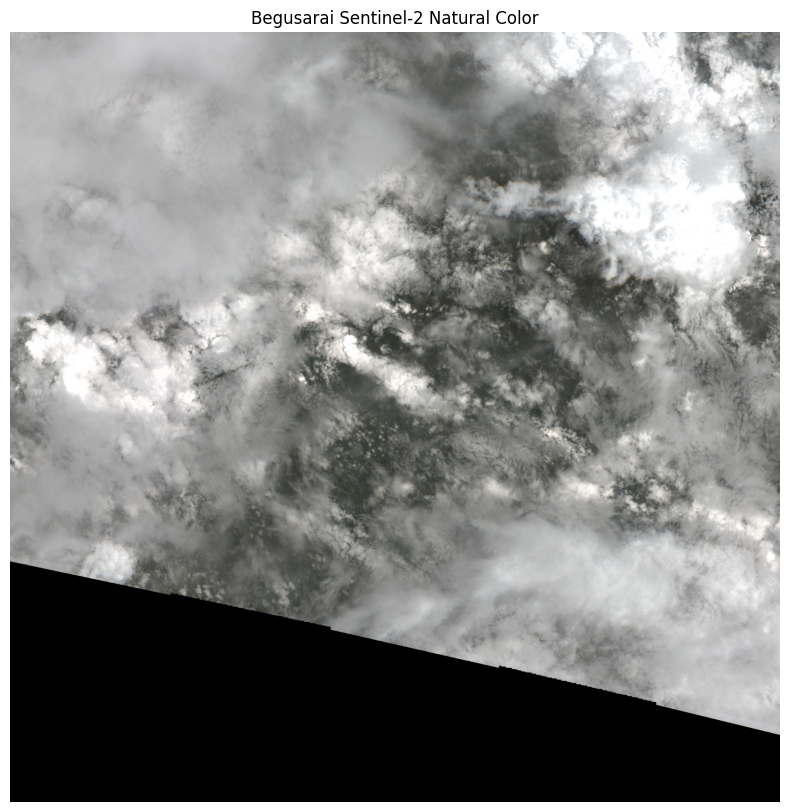

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def normalize(img):
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2), 0, 1)

rgb = np.dstack([
    normalize(b04),  # Red
    normalize(b03),  # Green
    normalize(b02)   # Blue
])

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Begusarai Sentinel-2 Natural Color")
plt.axis("off")
plt.show()

In [6]:
from pathlib import Path

# Change this to the location of your Sentinel-2 .SAFE folder
safe_path = Path("/path/to/your/S2_PRODUCT.SAFE")

# Find B04 and B08 JP2 files
b04_files = list(safe_path.rglob("*_B04_10m.jp2"))
b08_files = list(safe_path.rglob("*_B08_10m.jp2"))

print("B04:", b04_files)
print("B08:", b08_files)

b04_path = str(b04_files[0])
b08_path = str(b08_files[0])

print("\nB04 path:", b04_path)
print("B08 path:", b08_path)

B04: []
B08: []


IndexError: list index out of range

In [9]:
from pathlib import Path

safe_path = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/"
    "S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE"
)

print("SAFE exists:", safe_path.exists())
print("SAFE path:", safe_path)

SAFE exists: True
SAFE path: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE


In [10]:
# List files inside the Sentinel-2 SAFE folder

files = [p for p in safe_path.rglob("*") if p.is_file()]

print("Total files:", len(files))

for p in files[:100]:
    print(p)

Total files: 95
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/MTD_MSIL2A.xml
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/INSPIRE.xml
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809-ql.jpg
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/manifest.safe
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/HTML/UserProduct_index.xsl
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/HTML/banner_2.png
/content/drive/MyDrive/soa_ideathon_s6/data/Begusa

In [11]:
# Find the actual 10m B04 and B08 image files

b04_files = list(safe_path.rglob("*_B04_10m.jp2"))
b08_files = list(safe_path.rglob("*_B08_10m.jp2"))

print("B04:", b04_files)
print("B08:", b08_files)

b04_path = b04_files[0]
b08_path = b08_files[0]

print("\nB04 path:", b04_path)
print("B08 path:", b08_path)

B04: [PosixPath('/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B04_10m.jp2')]
B08: [PosixPath('/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B08_10m.jp2')]

B04 path: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B04_10m.jp2
B08 path: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B08_10m.jp2


In [12]:
import rasterio
import numpy as np

with rasterio.open(b04_path) as src:
    b04 = src.read(1).astype(np.float32)
    profile = src.profile

with rasterio.open(b08_path) as src:
    b08 = src.read(1).astype(np.float32)

print("B04 shape:", b04.shape)
print("B08 shape:", b08.shape)
print("B04 dtype:", b04.dtype)
print("B08 dtype:", b08.dtype)

B04 shape: (10980, 10980)
B08 shape: (10980, 10980)
B04 dtype: float32
B08 dtype: float32


In [13]:
# Calculate NDVI

denominator = b08 + b04

ndvi = np.divide(
    b08 - b04,
    denominator,
    out=np.zeros_like(b08, dtype=np.float32),
    where=denominator != 0
)

print("NDVI shape:", ndvi.shape)
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI shape: (10980, 10980)
NDVI min: -0.90815854
NDVI max: 0.9380904
NDVI mean: 0.020618424


In [14]:
from pathlib import Path

# Search for the district boundary GeoJSON
geojson_files = list(Path("/content/drive/MyDrive").rglob("*.geojson"))

print("GeoJSON files found:")
for f in geojson_files:
    print(f)

GeoJSON files found:


In [15]:
from pathlib import Path

# Search for likely boundary files
patterns = [
    "*district*",
    "*boundary*",
    "*target*",
    "*.shp",
    "*.gpkg",
    "*.geojson",
]

for pattern in patterns:
    print(f"\n--- Searching: {pattern} ---")
    found = list(Path("/content/drive/MyDrive").rglob(pattern))

    for f in found[:50]:
        print(f)


--- Searching: *district* ---

--- Searching: *boundary* ---

--- Searching: *target* ---

--- Searching: *.shp ---

--- Searching: *.gpkg ---

--- Searching: *.geojson ---


In [17]:
from pathlib import Path

matches = list(Path("/content/drive").rglob("target_districts.geojson"))

print("Matches found:", len(matches))

for f in matches:
    print(f)

Matches found: 1
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson


In [20]:
from pathlib import Path

matches = list(Path("/content/drive").rglob("*.geojson"))

print("GeoJSON files found:", len(matches))

for f in matches:
    print(f)

GeoJSON files found: 1
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson


In [21]:
geojson_path = "/content/drive/MyDrive/.../Sentinel-2/.../f02e26d2-253e-4fa6-9264-5af38412d8e3.geojson"

In [22]:
geojson_path = str(matches[0])

print(geojson_path)
print(Path(geojson_path).exists())

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson
True


In [23]:
import geopandas as gpd

geojson_path = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson"

districts = gpd.read_file(geojson_path)

print("CRS:", districts.crs)
print("Number of features:", len(districts))
print("Columns:", districts.columns.tolist())
print(districts.head())

CRS: EPSG:4326
Number of features: 3
Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']
        GID_2 GID_0 COUNTRY    GID_1 NAME_1 NL_NAME_1     NAME_2 VARNAME_2  \
0   IND.5.5_1   IND   India  IND.5_1  Bihar        NA  Begusarai        NA   
1  IND.5.10_1   IND   India  IND.5_1  Bihar        NA       Gaya        NA   
2  IND.5.15_1   IND   India  IND.5_1  Bihar        NA    Katihar  Kathihar   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA  District  District   NA  IN.BR.BE   
1        NA  District  District   NA  IN.BR.GA   
2        NA  District  District   NA  IN.BR.KT   

                                            geometry  
0  MULTIPOLYGON (((86.3072 25.3169, 86.2918 25.29...  
1  MULTIPOLYGON (((84.7315 25.0579, 84.748 25.053...  
2  MULTIPOLYGON (((87.5474 25.3309, 87.5376 25.33...  


In [24]:
begusarai = districts[districts["NAME_2"] == "Begusarai"].copy()

print("Features:", len(begusarai))
print("CRS:", begusarai.crs)
print("District:", begusarai["NAME_2"].tolist())

Features: 1
CRS: EPSG:4326
District: ['Begusarai']


<Axes: >

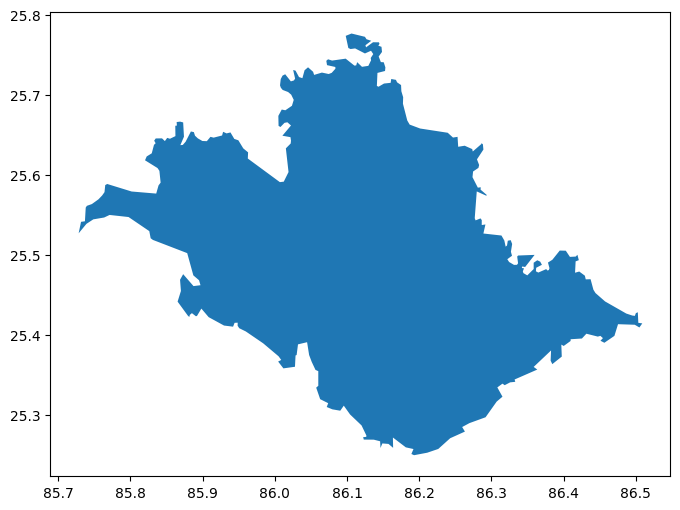

In [25]:
begusarai.plot(figsize=(8, 8))

In [26]:
from pathlib import Path

sentinel_dir = Path("/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2")

# Find Sentinel-2 band files
bands = {}

for f in sentinel_dir.rglob("*.jp2"):
    name = f.name.upper()

    for band in ["B02", "B03", "B04", "B08", "B11", "B12"]:
        if f"_{band}_" in name or f"_{band}." in name:
            bands[band] = f

print("Bands found:")

for band, path in sorted(bands.items()):
    print(f"{band}: {path}")

Bands found:
B02: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R20m/T45RUH_20260710T044701_B02_20m.jp2
B03: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R20m/T45RUH_20260710T044701_B03_20m.jp2
B04: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R20m/T45RUH_20260710T044701_B04_20m.jp2
B08: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m/T45RUH_20260710T044701_B08_10m.jp2
B11: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A

In [27]:
import rasterio

# Load the bands using the paths we just found
src_b02 = rasterio.open(bands["B02"])
src_b03 = rasterio.open(bands["B03"])
src_b04 = rasterio.open(bands["B04"])
src_b08 = rasterio.open(bands["B08"])
src_b11 = rasterio.open(bands["B11"])
src_b12 = rasterio.open(bands["B12"])

for name, src in [
    ("B02", src_b02),
    ("B03", src_b03),
    ("B04", src_b04),
    ("B08", src_b08),
    ("B11", src_b11),
    ("B12", src_b12)
]:
    print(f"\n{name}")
    print("  CRS:", src.crs)
    print("  Resolution:", src.res)
    print("  Shape:", (src.height, src.width))
    print("  Bounds:", src.bounds)


B02
  CRS: EPSG:32645
  Resolution: (20.0, 20.0)
  Shape: (5490, 5490)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B03
  CRS: EPSG:32645
  Resolution: (20.0, 20.0)
  Shape: (5490, 5490)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B04
  CRS: EPSG:32645
  Resolution: (20.0, 20.0)
  Shape: (5490, 5490)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B08
  CRS: EPSG:32645
  Resolution: (10.0, 10.0)
  Shape: (10980, 10980)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B11
  CRS: EPSG:32645
  Resolution: (20.0, 20.0)
  Shape: (5490, 5490)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B12
  CRS: EPSG:32645
  Resolution: (20.0, 20.0)
  Shape: (5490, 5490)
  Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)


In [28]:
# Reproject Begusarai boundary to Sentinel-2 CRS
begusarai_utm = begusarai.to_crs(src_b04.crs)

print("Original CRS:", begusarai.crs)
print("Reprojected CRS:", begusarai_utm.crs)
print("Bounds:", begusarai_utm.total_bounds)

Original CRS: EPSG:4326
Reprojected CRS: PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32645"]]
Bounds: [ 372229.52084222 2792863.55747338  450600.39012288 2851270.22972449]


In [29]:
from rasterio.mask import mask

b04_clipped, b04_transform = mask(
    src_b04,
    begusarai_utm.geometry,
    crop=True
)

print("Original B04 shape:", (src_b04.height, src_b04.width))
print("Clipped B04 shape:", b04_clipped.shape)
print("Clipped B04 transform:", b04_transform)

Original B04 shape: (5490, 5490)
Clipped B04 shape: (1, 358, 1879)
Clipped B04 transform: | 20.00, 0.00, 372220.00|
| 0.00,-20.00, 2800020.00|
| 0.00, 0.00, 1.00|


In [30]:
from rasterio.mask import mask

clipped = {}
transforms = {}

for band_name, src in [
    ("B02", src_b02),
    ("B03", src_b03),
    ("B04", src_b04),
    ("B08", src_b08),
    ("B11", src_b11),
    ("B12", src_b12)
]:
    data, transform = mask(
        src,
        begusarai_utm.geometry,
        crop=True
    )

    clipped[band_name] = data[0]
    transforms[band_name] = transform

    print(f"{band_name}: {data.shape}")

B02: (1, 358, 1879)
B03: (1, 358, 1879)
B04: (1, 358, 1879)
B08: (1, 716, 3758)
B11: (1, 358, 1879)
B12: (1, 358, 1879)


In [31]:
from rasterio.enums import Resampling
from rasterio.transform import Affine

# B08 is 10 m; convert it to 20 m
b08_20m = src_b08.read(
    1,
    out_shape=(358, 1879),
    resampling=Resampling.bilinear
)

# Use the same spatial transform as the 20 m bands
b08_20m_transform = transforms["B04"]

print("B08 original:", clipped["B08"].shape)
print("B08 aligned:", b08_20m.shape)
print("B08 resolution: 20 m")

B08 original: (716, 3758)
B08 aligned: (358, 1879)
B08 resolution: 20 m


In [32]:
import numpy as np
from rasterio.warp import reproject
from rasterio.enums import Resampling

# Create an empty array with exactly the B04 dimensions
b08_aligned = np.empty_like(clipped["B04"], dtype=np.float32)

# Reproject/resample B08 onto the exact B04 grid
reproject(
    source=clipped["B08"].astype(np.float32),
    destination=b08_aligned,
    src_transform=transforms["B08"],
    src_crs=src_b08.crs,
    dst_transform=transforms["B04"],
    dst_crs=src_b04.crs,
    resampling=Resampling.bilinear
)

print("B04 shape:", clipped["B04"].shape)
print("B08 aligned shape:", b08_aligned.shape)
print("B04 transform:", transforms["B04"])
print("B08 aligned to B04 grid: Yes")

B04 shape: (358, 1879)
B08 aligned shape: (358, 1879)
B04 transform: | 20.00, 0.00, 372220.00|
| 0.00,-20.00, 2800020.00|
| 0.00, 0.00, 1.00|
B08 aligned to B04 grid: Yes


In [33]:
import numpy as np

# Convert to float to avoid integer arithmetic
red = clipped["B04"].astype(np.float32)
nir = b08_aligned.astype(np.float32)

# Avoid division by zero
denominator = nir + red

ndvi = np.where(
    denominator != 0,
    (nir - red) / denominator,
    np.nan
)

print("NDVI shape:", ndvi.shape)
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI shape: (358, 1879)
NDVI min: -0.390448
NDVI max: 1.0
NDVI mean: 0.03577941


/tmp/ipykernel_103892/1364461172.py:12: RuntimeWarning: invalid value encountered in divide
  (nir - red) / denominator,


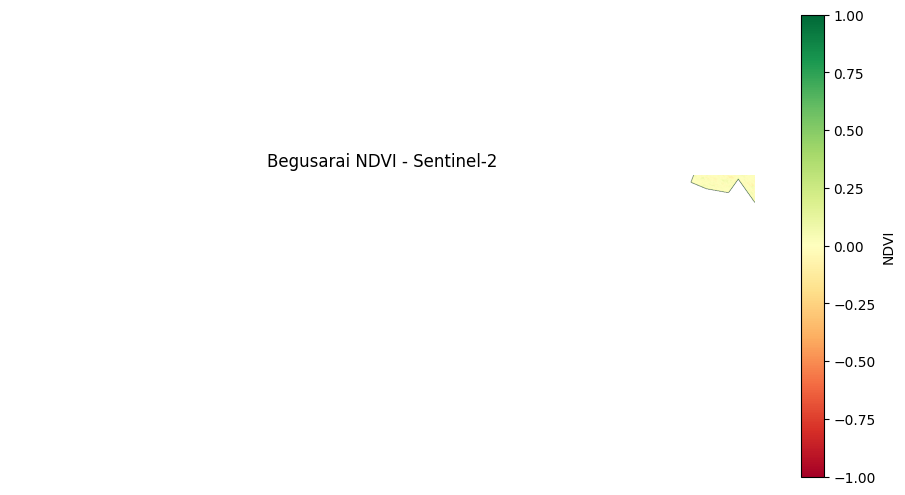

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

plt.colorbar(label="NDVI")
plt.title("Begusarai NDVI - Sentinel-2")
plt.axis("off")

plt.show()

In [35]:
from pathlib import Path
import rasterio

output_dir = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/processed"
)
output_dir.mkdir(parents=True, exist_ok=True)

ndvi_path = output_dir / "Begusarai_NDVI_20m.tif"

with rasterio.open(
    ndvi_path,
    "w",
    driver="GTiff",
    height=ndvi.shape[0],
    width=ndvi.shape[1],
    count=1,
    dtype="float32",
    crs=src_b04.crs,
    transform=transforms["B04"],
    nodata=np.nan,
    compress="deflate"
) as dst:
    dst.write(ndvi.astype(np.float32), 1)

print("Saved:", ndvi_path)
print("Exists:", ndvi_path.exists())

Saved: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/processed/Begusarai_NDVI_20m.tif
Exists: True


In [36]:
green = clipped["B03"].astype(np.float32)
nir = b08_aligned.astype(np.float32)

denominator = green + nir

ndwi = np.where(
    denominator != 0,
    (green - nir) / denominator,
    np.nan
)

print("NDWI shape:", ndwi.shape)
print("NDWI min:", np.nanmin(ndwi))
print("NDWI max:", np.nanmax(ndwi))
print("NDWI mean:", np.nanmean(ndwi))

NDWI shape: (358, 1879)
NDWI min: -1.0
NDWI max: 0.38760117
NDWI mean: -0.017525641


/tmp/ipykernel_103892/2176581634.py:8: RuntimeWarning: invalid value encountered in divide
  (green - nir) / denominator,


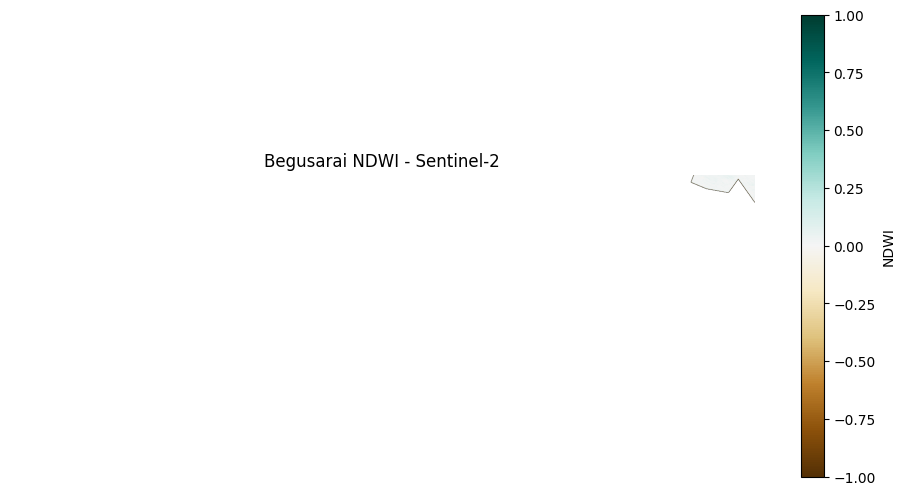

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(ndwi, cmap="BrBG", vmin=-1, vmax=1)

plt.colorbar(label="NDWI")
plt.title("Begusarai NDWI - Sentinel-2")
plt.axis("off")

plt.show()

In [38]:
ndwi_path = output_dir / "Begusarai_NDWI_20m.tif"

with rasterio.open(
    ndwi_path,
    "w",
    driver="GTiff",
    height=ndwi.shape[0],
    width=ndwi.shape[1],
    count=1,
    dtype="float32",
    crs=src_b03.crs,
    transform=transforms["B03"],
    nodata=np.nan,
    compress="deflate"
) as dst:
    dst.write(ndwi.astype(np.float32), 1)

print("Saved:", ndwi_path)
print("Exists:", ndwi_path.exists())

Saved: /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/processed/Begusarai_NDWI_20m.tif
Exists: True


In [39]:
from rasterio.warp import reproject
from rasterio.enums import Resampling

# Create array on the exact B04 grid
b11_aligned = np.empty_like(clipped["B04"], dtype=np.float32)

reproject(
    source=clipped["B11"].astype(np.float32),
    destination=b11_aligned,
    src_transform=transforms["B11"],
    src_crs=src_b11.crs,
    dst_transform=transforms["B04"],
    dst_crs=src_b04.crs,
    resampling=Resampling.bilinear
)

print("B11 original shape:", clipped["B11"].shape)
print("B11 aligned shape:", b11_aligned.shape)

B11 original shape: (358, 1879)
B11 aligned shape: (358, 1879)


In [40]:
swir = b11_aligned

denominator = swir + nir

ndbi = np.where(
    denominator != 0,
    (swir - nir) / denominator,
    np.nan
)

print("NDBI shape:", ndbi.shape)
print("NDBI min:", np.nanmin(ndbi))
print("NDBI max:", np.nanmax(ndbi))
print("NDBI mean:", np.nanmean(ndbi))

NDBI shape: (358, 1879)
NDBI min: -1.0
NDBI max: 0.31010103
NDBI mean: -0.14589624


/tmp/ipykernel_103892/1277234866.py:7: RuntimeWarning: invalid value encountered in divide
  (swir - nir) / denominator,


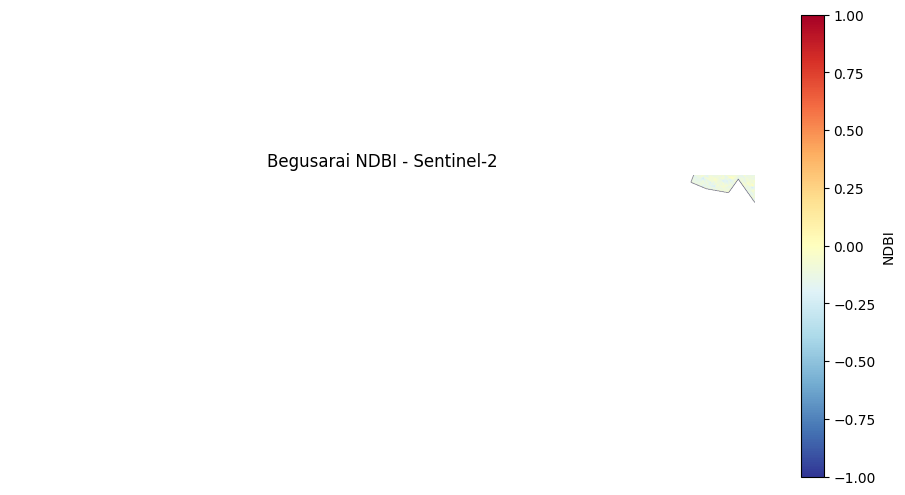

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(ndbi, cmap="RdYlBu_r", vmin=-1, vmax=1)

plt.colorbar(label="NDBI")
plt.title("Begusarai NDBI - Sentinel-2")
plt.axis("off")

plt.show()

In [42]:
print("        MIN        MAX        MEAN")
print("--------------------------------------")
print(f"NDVI   {np.nanmin(ndvi):.4f}   {np.nanmax(ndvi):.4f}   {np.nanmean(ndvi):.4f}")
print(f"NDWI   {np.nanmin(ndwi):.4f}   {np.nanmax(ndwi):.4f}   {np.nanmean(ndwi):.4f}")
print(f"NDBI   {np.nanmin(ndbi):.4f}   {np.nanmax(ndbi):.4f}   {np.nanmean(ndbi):.4f}")

        MIN        MAX        MEAN
--------------------------------------
NDVI   -0.3904   1.0000   0.0358
NDWI   -1.0000   0.3876   -0.0175
NDBI   -1.0000   0.3101   -0.1459


In [43]:
for name, arr in [
    ("NDVI", ndvi),
    ("NDWI", ndwi),
    ("NDBI", ndbi)
]:
    valid = arr[np.isfinite(arr)]

    print(f"\n{name}")
    print("Valid pixels:", len(valid))
    print("P5 :", np.percentile(valid, 5))
    print("P25:", np.percentile(valid, 25))
    print("P50:", np.percentile(valid, 50))
    print("P75:", np.percentile(valid, 75))
    print("P95:", np.percentile(valid, 95))


NDVI
Valid pixels: 6054
P5 : -0.053652074
P25: -0.014801436
P50: 0.002814786
P75: 0.019591661
P95: 0.067559205

NDWI
Valid pixels: 6054
P5 : -0.012857977
P25: 0.0077809305
P50: 0.015888391
P75: 0.02591348
P95: 0.050289646

NDBI
Valid pixels: 6054
P5 : -0.21080868
P25: -0.14156109
P50: -0.116725326
P75: -0.0918127
P95: -0.045944214


In [44]:
print("B04 nodata:", src_b04.nodata)
print("B08 nodata:", src_b08.nodata)
print("B11 nodata:", src_b11.nodata)

print("\nB04 statistics:")
print("min:", np.nanmin(clipped["B04"]))
print("max:", np.nanmax(clipped["B04"]))

print("\nB08 statistics:")
print("min:", np.nanmin(clipped["B08"]))
print("max:", np.nanmax(clipped["B08"]))

B04 nodata: None
B08 nodata: None
B11 nodata: None

B04 statistics:
min: 0
max: 7585

B08 statistics:
min: 0
max: 7670


In [45]:
for name, arr in [
    ("B04", clipped["B04"]),
    ("B08", clipped["B08"]),
    ("B11", clipped["B11"])
]:
    print(
        name,
        "non-zero:",
        np.count_nonzero(arr),
        "/",
        arr.size,
        f"({100*np.count_nonzero(arr)/arr.size:.2f}%)"
    )

B04 non-zero: 5822 / 672682 (0.87%)
B08 non-zero: 23283 / 2690728 (0.87%)
B11 non-zero: 5822 / 672682 (0.87%)


In [46]:
print("Begusarai bounds in UTM:")
print(begusarai_utm.total_bounds)

print("\nB04 bounds:")
print(src_b04.bounds)

print("\nB04 CRS:")
print(src_b04.crs)

print("\nBegusarai CRS:")
print(begusarai_utm.crs)

Begusarai bounds in UTM:
[ 372229.52084222 2792863.55747338  450600.39012288 2851270.22972449]

B04 bounds:
BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)

B04 CRS:
EPSG:32645

Begusarai CRS:
PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32645"]]


In [47]:
from pathlib import Path

sentinel_dir = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2"
)

safe_files = list(sentinel_dir.glob("*.SAFE"))

print("Sentinel-2 products found:", len(safe_files))

for f in safe_files:
    print(f.name)

Sentinel-2 products found: 1
S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE


In [48]:
from rasterio.mask import mask
import numpy as np

def clip_band_to_begusarai(src, geometry):
    """
    Clip a Sentinel-2 raster to the Begusarai boundary.
    """
    clipped_data, transform = mask(
        src,
        geometry,
        crop=True
    )

    return clipped_data[0], transform

In [49]:
b04_test, b04_test_transform = clip_band_to_begusarai(
    src_b04,
    begusarai_utm.geometry
)

print("B04 clipped shape:", b04_test.shape)
print("B04 transform:", b04_test_transform)

B04 clipped shape: (358, 1879)
B04 transform: | 20.00, 0.00, 372220.00|
| 0.00,-20.00, 2800020.00|
| 0.00, 0.00, 1.00|


In [50]:
valid_pixels = np.count_nonzero(b04_test)

total_pixels = b04_test.size

coverage = 100 * valid_pixels / total_pixels

print("Valid pixels:", valid_pixels)
print("Total pixels:", total_pixels)
print(f"Coverage: {coverage:.2f}%")

Valid pixels: 5822
Total pixels: 672682
Coverage: 0.87%


In [51]:
from pathlib import Path

sentinel_dir = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2"
)

safe_files = list(sentinel_dir.rglob("*.SAFE"))

print("SAFE products found:", len(safe_files))

for f in safe_files:
    print(f)

SAFE products found: 1
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE


In [52]:
archives = []

for pattern in ["*.zip", "*.ZIP"]:
    archives.extend(sentinel_dir.rglob(pattern))

print("ZIP files found:", len(archives))

for f in archives:
    print(f)

ZIP files found: 0


In [53]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd


# ============================================================
# 1. PATHS
# ============================================================

sentinel_dir = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2"
)

geojson_path = (
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/"
    "sentinel2/target_districts.geojson"
)

output_dir = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/processed"
)

output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. LOAD BEGUSARAI BOUNDARY
# ============================================================

districts = gpd.read_file(geojson_path)

begusarai = districts[
    districts["NAME_2"] == "Begusarai"
].copy()

if len(begusarai) == 0:
    raise ValueError("Begusarai boundary not found.")

print("Begusarai boundary loaded")
print("CRS:", begusarai.crs)


# ============================================================
# 3. FIND SENTINEL-2 BAND FILES
# ============================================================

def find_band_files(band, resolution):
    """
    Find all Sentinel-2 JP2 files for a band and resolution.
    """

    files = []

    pattern = f"*_{band}_{resolution}m.jp2"

    for safe in sentinel_dir.glob("*.SAFE"):
        files.extend(safe.rglob(pattern))

    return sorted(files)


# ============================================================
# 4. MOSAIC BAND
# ============================================================

def mosaic_band(band, resolution):
    """
    Mosaic all available Sentinel-2 tiles for one band.
    """

    files = find_band_files(band, resolution)

    print(f"\n{band} ({resolution}m)")
    print("Files found:", len(files))

    if len(files) == 0:
        raise FileNotFoundError(
            f"No {band} {resolution}m files found."
        )

    sources = []

    try:
        for file in files:
            print("  ", file.name)
            sources.append(rasterio.open(file))

        mosaic, transform = merge(sources)

        crs = sources[0].crs

    finally:
        for src in sources:
            src.close()

    return mosaic[0].astype(np.float32), transform, crs


# ============================================================
# 5. CREATE COMMON 20 m GRID FROM B04
# ============================================================

b04_full, b04_transform, common_crs = mosaic_band("B04", 20)

print("\nCommon CRS:", common_crs)
print("B04 mosaic shape:", b04_full.shape)


# Reproject Begusarai boundary to Sentinel-2 CRS
begusarai_utm = begusarai.to_crs(common_crs)

print("Begusarai reprojected CRS:", begusarai_utm.crs)


# ============================================================
# 6. CLIP B04
# ============================================================

# Create an in-memory raster-like source for masking
from rasterio.io import MemoryFile

def clip_array(data, transform, crs, geometry):
    """
    Clip a NumPy raster array using a geometry.
    """

    height, width = data.shape

    profile = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "float32",
        "crs": crs,
        "transform": transform,
        "nodata": 0
    }

    with MemoryFile() as memfile:

        with memfile.open(**profile) as dataset:
            dataset.write(data, 1)

        with memfile.open() as dataset:
            clipped, clipped_transform = mask(
                dataset,
                begusarai_utm.geometry,
                crop=True
            )

    return clipped[0], clipped_transform


b04, common_transform = clip_array(
    b04_full,
    b04_transform,
    common_crs,
    begusarai_utm.geometry
)

print("\nB04 clipped shape:", b04.shape)


# ============================================================
# 7. FUNCTION TO MOSAIC + ALIGN + CLIP ANY BAND
# ============================================================

def process_band(
    band,
    resolution,
    destination_shape,
    destination_transform,
    destination_crs,
    geometry
):
    """
    Mosaic a Sentinel-2 band, align it to the B04 20 m grid,
    then clip it to Begusarai.
    """

    data, transform, crs = mosaic_band(
        band,
        resolution
    )

    # Allocate destination on common B04 grid
    aligned = np.zeros(
        destination_shape,
        dtype=np.float32
    )

    reproject(
        source=data,
        destination=aligned,
        src_transform=transform,
        src_crs=crs,
        dst_transform=destination_transform,
        dst_crs=destination_crs,
        resampling=Resampling.bilinear
    )

    # Clip to Begusarai
    clipped, clipped_transform = clip_array(
        aligned,
        destination_transform,
        destination_crs,
        geometry
    )

    return clipped


# ============================================================
# 8. PROCESS ALL SIX SPECTRAL BANDS
# ============================================================

features = {}

# B02 - Blue
features["B02"] = process_band(
    "B02",
    20,
    b04.shape,
    common_transform,
    common_crs,
    begusarai_utm.geometry
)

# B03 - Green
features["B03"] = process_band(
    "B03",
    20,
    b04.shape,
    common_transform,
    common_crs,
    begusarai_utm.geometry
)

# B04 - Red
features["B04"] = b04

# B08 - NIR
features["B08"] = process_band(
    "B08",
    10,
    b04.shape,
    common_transform,
    common_crs,
    begusarai_utm.geometry
)

# B11 - SWIR1
features["B11"] = process_band(
    "B11",
    20,
    b04.shape,
    common_transform,
    common_crs,
    begusarai_utm.geometry
)

# B12 - SWIR2
features["B12"] = process_band(
    "B12",
    20,
    b04.shape,
    common_transform,
    common_crs,
    begusarai_utm.geometry
)


# ============================================================
# 9. CREATE VALID PIXEL MASK
# ============================================================

valid = (
    (features["B02"] > 0) &
    (features["B03"] > 0) &
    (features["B04"] > 0) &
    (features["B08"] > 0) &
    (features["B11"] > 0) &
    (features["B12"] > 0)
)

print("\nValid pixels:")
print(np.count_nonzero(valid))
print("Total pixels:", valid.size)
print(
    "Coverage:",
    f"{100 * np.count_nonzero(valid) / valid.size:.2f}%"
)


# ============================================================
# 10. CALCULATE NDVI
# ============================================================

red = features["B04"]
nir = features["B08"]

ndvi_den = nir + red

ndvi = np.full(
    red.shape,
    np.nan,
    dtype=np.float32
)

np.divide(
    nir - red,
    ndvi_den,
    out=ndvi,
    where=(
        (ndvi_den != 0) &
        valid
    )
)


# ============================================================
# 11. CALCULATE NDWI
# ============================================================

green = features["B03"]

ndwi_den = green + nir

ndwi = np.full(
    red.shape,
    np.nan,
    dtype=np.float32
)

np.divide(
    green - nir,
    ndwi_den,
    out=ndwi,
    where=(
        (ndwi_den != 0) &
        valid
    )
)


# ============================================================
# 12. CALCULATE NDBI
# ============================================================

swir1 = features["B11"]

ndbi_den = swir1 + nir

ndbi = np.full(
    red.shape,
    np.nan,
    dtype=np.float32
)

np.divide(
    swir1 - nir,
    ndbi_den,
    out=ndbi,
    where=(
        (ndbi_den != 0) &
        valid
    )
)


# ============================================================
# 13. ADD INDICES TO FEATURE DICTIONARY
# ============================================================

features["NDVI"] = ndvi
features["NDWI"] = ndwi
features["NDBI"] = ndbi


# ============================================================
# 14. PRINT FEATURE STATISTICS
# ============================================================

print("\nFeature statistics")

for name, arr in features.items():

    valid_values = arr[np.isfinite(arr)]

    print(
        f"{name:5s} | "
        f"min={np.min(valid_values):.4f} | "
        f"max={np.max(valid_values):.4f} | "
        f"mean={np.mean(valid_values):.4f}"
    )


# ============================================================
# 15. CREATE 9-BAND FEATURE STACK
# ============================================================

feature_names = [
    "B02",
    "B03",
    "B04",
    "B08",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI"
]

stack = np.stack(
    [features[name] for name in feature_names]
).astype(np.float32)

print("\nFeature stack shape:")
print(stack.shape)


# ============================================================
# 16. SAVE FEATURE STACK
# ============================================================

feature_stack_path = (
    output_dir /
    "Begusarai_feature_stack_20m.tif"
)

profile = {
    "driver": "GTiff",
    "height": stack.shape[1],
    "width": stack.shape[2],
    "count": stack.shape[0],
    "dtype": "float32",
    "crs": common_crs,
    "transform": common_transform,
    "nodata": np.nan,
    "compress": "deflate"
}

with rasterio.open(
    feature_stack_path,
    "w",
    **profile
) as dst:

    for i, name in enumerate(feature_names, start=1):

        dst.write(stack[i - 1], i)
        dst.set_band_description(i, name)


print("\nFeature stack saved:")
print(feature_stack_path)
print("Exists:", feature_stack_path.exists())

Begusarai boundary loaded
CRS: EPSG:4326

B04 (20m)
Files found: 1
   T45RUH_20260710T044701_B04_20m.jp2

Common CRS: EPSG:32645
B04 mosaic shape: (5490, 5490)
Begusarai reprojected CRS: PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32645"]]

B04 clipped shape: (358, 1879)

B02 (20m)
Files found: 1
   T45RUH_20260710T044701_B02_20m.jp2

B03 (20m)
Files found: 1
   T45RUH_20260710T044701_B03_20m.jp2

B08 (10m)
Files found: 1
   T45RUH_20260710T044701_B08

In [54]:
import geopandas as gpd

geojson_path = (
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/"
    "sentinel2/target_districts.geojson"
)

districts = gpd.read_file(geojson_path)

begusarai = districts[
    districts["NAME_2"] == "Begusarai"
].copy()

print(begusarai.to_crs("EPSG:4326").total_bounds)

[85.7284 25.2499 86.5088 25.7768]


In [55]:
# Install the MGRS package if needed
!pip -q install mgrs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.1 MB/s eta 0:00:00


In [56]:
import mgrs

m = mgrs.MGRS()

bounds = begusarai.to_crs("EPSG:4326").total_bounds

min_lon, min_lat, max_lon, max_lat = bounds

corners = {
    "SW": (min_lat, min_lon),
    "NW": (max_lat, min_lon),
    "SE": (min_lat, max_lon),
    "NE": (max_lat, max_lon),
}

print("Begusarai corner MGRS tiles:")

for name, (lat, lon) in corners.items():
    tile = m.toMGRS(lat, lon, MGRSPrecision=5)
    print(f"{name}: {tile}")

Begusarai corner MGRS tiles:
SW: 45RUH7193793225
NW: 45RUJ7249551581
SE: 45RVH5053392709
NE: 45RVJ5074851058


In [57]:
corners = {
    "SW": "45RUH7193793225",
    "NW": "45RUJ7249551581",
    "SE": "45RVH5053392709",
    "NE": "45RVJ5074851058"
}

for name, coord in corners.items():
    lat, lon = m.toLatLon(coord)
    print(f"{name}: latitude={lat:.6f}, longitude={lon:.6f}")

SW: latitude=25.249895, longitude=85.728398
NW: latitude=25.776795, longitude=85.728398
SE: latitude=25.249893, longitude=86.508795
NE: latitude=25.776800, longitude=86.508791


In [58]:
from shapely.geometry import Polygon
import geopandas as gpd

# Begusarai AOI coordinates
sw = (85.728398, 25.249895)
nw = (85.728398, 25.776795)
se = (86.508795, 25.249893)
ne = (86.508791, 25.776800)

# Create polygon
aoi = Polygon([
    sw,
    se,
    ne,
    nw,
    sw
])

# Create GeoDataFrame
aoi_gdf = gpd.GeoDataFrame(
    {"name": ["Begusarai_AOI"]},
    geometry=[aoi],
    crs="EPSG:4326"
)

print(aoi_gdf)

            name                                           geometry
0  Begusarai_AOI  POLYGON ((85.7284 25.2499, 86.5088 25.24989, 8...


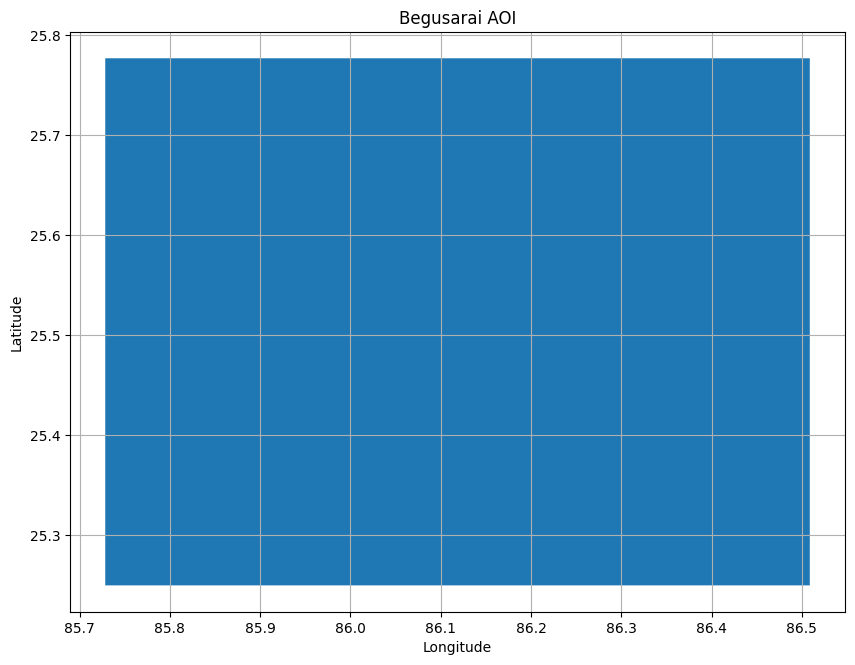

In [59]:
import matplotlib.pyplot as plt

aoi_gdf.plot(figsize=(10, 8))

plt.title("Begusarai AOI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()

plt.show()

In [60]:
import os

os.makedirs("data/geojson", exist_ok=True)

geojson_path = "data/geojson/begusarai_aoi.geojson"

aoi_gdf.to_file(
    geojson_path,
    driver="GeoJSON"
)

print("AOI saved successfully:")
print(geojson_path)

AOI saved successfully:
data/geojson/begusarai_aoi.geojson


In [61]:
import geopandas as gpd

geojson_path = "data/geojson/begusarai_aoi.geojson"

aoi_gdf = gpd.read_file(geojson_path)

print("AOI CRS:", aoi_gdf.crs)
print("AOI bounds:", aoi_gdf.total_bounds)

AOI CRS: EPSG:4326
AOI bounds: [85.728398 25.249893 86.508795 25.7768  ]


In [63]:
import os

sentinel_dir = "data/raw/sentinel2"

for root, dirs, files in os.walk(sentinel_dir):
    for file in files:
        if file.endswith(".jp2"):
            print(os.path.join(root, file))

In [64]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".jp2"):
            print(os.path.join(root, file))

./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B03.jp2
./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B07.jp2
./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B06.jp2
./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B02.jp2
./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B01.jp2
./drive/MyDrive/soaideathon s6/data/begu

In [65]:
import os

base_dir = (
    "./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/"
    "S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/"
    "GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R10m"
)

b02_path = os.path.join(
    base_dir,
    "T45RUH_20260710T044701_B02_10m.jp2"
)

b03_path = os.path.join(
    base_dir,
    "T45RUH_20260710T044701_B03_10m.jp2"
)

b04_path = os.path.join(
    base_dir,
    "T45RUH_20260710T044701_B04_10m.jp2"
)

b08_path = os.path.join(
    base_dir,
    "T45RUH_20260710T044701_B08_10m.jp2"
)

print("B02:", os.path.exists(b02_path))
print("B03:", os.path.exists(b03_path))
print("B04:", os.path.exists(b04_path))
print("B08:", os.path.exists(b08_path))

B02: True
B03: True
B04: True
B08: True


In [66]:
with rasterio.open(b04_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)

CRS: EPSG:32645
Resolution: (10.0, 10.0)
Width: 10980
Height: 10980


In [67]:
from rasterio.mask import mask

with rasterio.open(b04_path) as src:

    # Convert AOI to Sentinel-2 CRS
    aoi_projected = aoi_gdf.to_crs(src.crs)

    clipped_b04, clipped_transform = mask(
        src,
        aoi_projected.geometry,
        crop=True
    )

    clipped_b04 = clipped_b04[0]

print("Original B04 shape:", (src.height, src.width))
print("Clipped B04 shape:", clipped_b04.shape)

Original B04 shape: (10980, 10980)
Clipped B04 shape: (732, 3787)


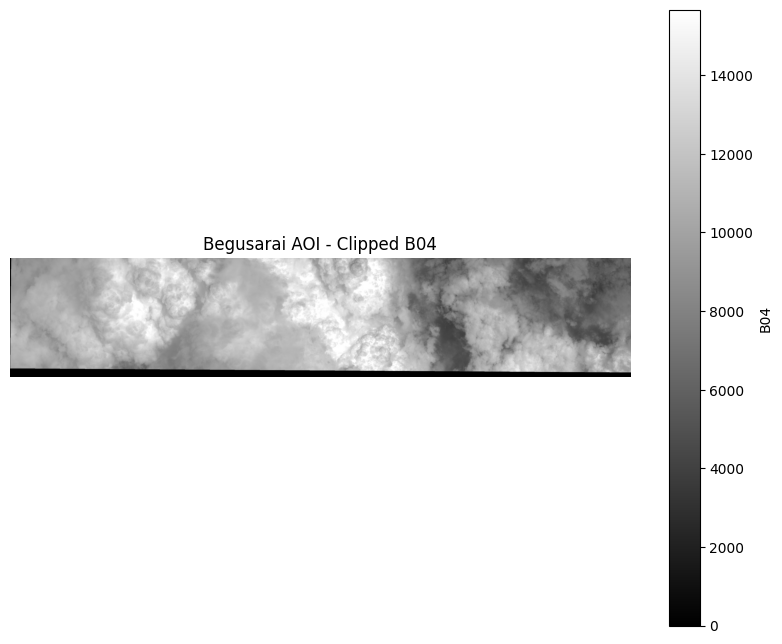

In [68]:
plt.figure(figsize=(10, 8))

plt.imshow(clipped_b04, cmap="gray")

plt.title("Begusarai AOI - Clipped B04")
plt.axis("off")
plt.colorbar(label="B04")

plt.show()

In [69]:
import os
import rasterio
from rasterio.mask import mask

# Output directory
output_dir = "./drive/MyDrive/soaideathon s6/data/begusarai/processed"

os.makedirs(output_dir, exist_ok=True)

# Sentinel-2 bands
bands = {
    "B02": b02_path,
    "B03": b03_path,
    "B04": b04_path,
    "B08": b08_path
}

clipped_bands = {}

for band_name, band_path in bands.items():

    with rasterio.open(band_path) as src:

        # Convert AOI to the raster CRS
        aoi_projected = aoi_gdf.to_crs(src.crs)

        # Clip
        clipped, transform = mask(
            src,
            aoi_projected.geometry,
            crop=True
        )

        # Save metadata
        profile = src.profile.copy()
        profile.update({
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": transform,
            "driver": "GTiff"
        })

        # Output path
        output_path = os.path.join(
            output_dir,
            f"begusarai_{band_name}_10m_clipped.tif"
        )

        # Save GeoTIFF
        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(clipped)

        # Store array for later processing
        clipped_bands[band_name] = clipped[0]

        print(f"{band_name} saved → {output_path}")

B02 saved → ./drive/MyDrive/soaideathon s6/data/begusarai/processed/begusarai_B02_10m_clipped.tif
B03 saved → ./drive/MyDrive/soaideathon s6/data/begusarai/processed/begusarai_B03_10m_clipped.tif
B04 saved → ./drive/MyDrive/soaideathon s6/data/begusarai/processed/begusarai_B04_10m_clipped.tif
B08 saved → ./drive/MyDrive/soaideathon s6/data/begusarai/processed/begusarai_B08_10m_clipped.tif


In [70]:
for band, array in clipped_bands.items():
    print(band, array.shape)

B02 (732, 3787)
B03 (732, 3787)
B04 (732, 3787)
B08 (732, 3787)


In [71]:
import numpy as np

# Extract the four bands
blue  = clipped_bands["B02"].astype(np.float32)
green = clipped_bands["B03"].astype(np.float32)
red   = clipped_bands["B04"].astype(np.float32)
nir   = clipped_bands["B08"].astype(np.float32)

# Create 4-band stack
sentinel_stack = np.stack(
    [blue, green, red, nir],
    axis=-1
)

print("Sentinel-2 stack shape:", sentinel_stack.shape)
print("Data type:", sentinel_stack.dtype)

Sentinel-2 stack shape: (732, 3787, 4)
Data type: float32


In [72]:
# Avoid division by zero
denominator = nir + red

ndvi = np.divide(
    nir - red,
    denominator,
    out=np.zeros_like(nir, dtype=np.float32),
    where=denominator != 0
)

print("NDVI shape:", ndvi.shape)
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))

NDVI shape: (732, 3787)
NDVI min: -0.18497162
NDVI max: 0.21064596


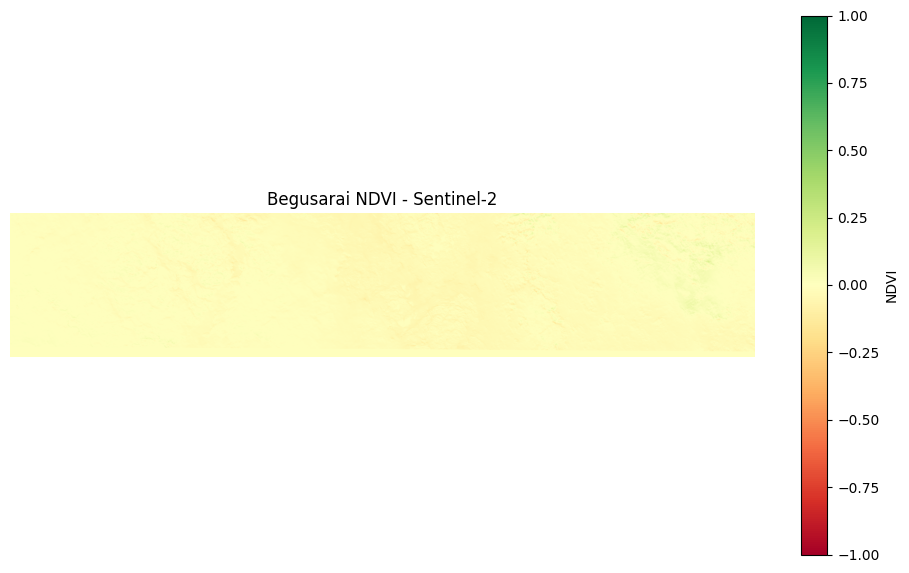

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

plt.title("Begusarai NDVI - Sentinel-2")
plt.axis("off")
plt.colorbar(label="NDVI")

plt.show()

In [74]:
print("NDVI shape:", ndvi.shape)
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI shape: (732, 3787)
NDVI min: -0.18497162
NDVI max: 0.21064596
NDVI mean: -0.0148752555


In [75]:
# Mark invalid pixels
valid_mask = np.isfinite(ndvi)

# Keep only valid NDVI range
valid_mask &= (ndvi >= -1) & (ndvi <= 1)

print("Valid pixels:", np.sum(valid_mask))
print("Total pixels:", ndvi.size)
print("Valid percentage:", 100 * np.sum(valid_mask) / ndvi.size)

Valid pixels: 2772084
Total pixels: 2772084
Valid percentage: 100.0


In [76]:
# Sentinel-2 reflectance scaling
sentinel_stack_reflectance = sentinel_stack / 10000.0

# Clip possible out-of-range values
sentinel_stack_reflectance = np.clip(
    sentinel_stack_reflectance,
    0,
    1
)

print("Stack shape:", sentinel_stack_reflectance.shape)
print("Min:", sentinel_stack_reflectance.min())
print("Max:", sentinel_stack_reflectance.max())

Stack shape: (732, 3787, 4)
Min: 0.0
Max: 1.0


In [77]:
features = np.dstack([
    sentinel_stack_reflectance,
    ndvi
])

print("Final feature stack:", features.shape)

Final feature stack: (732, 3787, 5)


In [78]:
feature_path = os.path.join(
    output_dir,
    "begusarai_sentinel2_features.npy"
)

np.save(feature_path, features)

print("Feature stack saved:")
print(feature_path)

Feature stack saved:
./drive/MyDrive/soaideathon s6/data/begusarai/processed/begusarai_sentinel2_features.npy


In [79]:
scl_path = (
    "./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2/"
    "S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/"
    "GRANULE/L2A_T45RUH_A009627_20260710T045042/IMG_DATA/R20m/"
    "T45RUH_20260710T044701_SCL_20m.jp2"
)

with rasterio.open(scl_path) as src:
    print("SCL CRS:", src.crs)
    print("SCL resolution:", src.res)

SCL CRS: EPSG:32645
SCL resolution: (20.0, 20.0)


In [80]:
with rasterio.open(scl_path) as src:

    aoi_scl = aoi_gdf.to_crs(src.crs)

    scl_clipped, scl_transform = mask(
        src,
        aoi_scl.geometry,
        crop=True
    )

    scl = scl_clipped[0]

print("SCL shape:", scl.shape)

SCL shape: (366, 1894)


In [81]:
from rasterio.warp import reproject, Resampling

# Target dimensions = your 10 m Sentinel-2 bands
target_height, target_width = ndvi.shape

# Create empty 10 m SCL array
scl_10m = np.zeros(
    (target_height, target_width),
    dtype=np.uint8
)

with rasterio.open(scl_path) as src:

    aoi_scl = aoi_gdf.to_crs(src.crs)

    # Get the transform of the clipped SCL
    scl_clipped, scl_transform = mask(
        src,
        aoi_scl.geometry,
        crop=True
    )

    scl = scl_clipped[0]

# Resample 20 m SCL → 10 m grid
reproject(
    source=scl,
    destination=scl_10m,
    src_transform=scl_transform,
    src_crs=src.crs,
    dst_transform=clipped_transform,
    dst_crs=src.crs,
    resampling=Resampling.nearest
)

print("Original SCL:", scl.shape)
print("Resampled SCL:", scl_10m.shape)

Original SCL: (366, 1894)
Resampled SCL: (732, 3787)


In [82]:
unique, counts = np.unique(scl_10m, return_counts=True)

print("SCL classes:")
for value, count in zip(unique, counts):
    print(f"Class {value}: {count} pixels")

SCL classes:
Class 0: 154428 pixels
Class 8: 693348 pixels
Class 9: 1923284 pixels
Class 10: 1024 pixels


In [83]:
total = scl_10m.size

for value, count in zip(unique, counts):
    print(
        f"Class {value}: "
        f"{count:,} pixels "
        f"({count / total * 100:.2f}%)"
    )

Class 0: 154,428 pixels (5.57%)
Class 8: 693,348 pixels (25.01%)
Class 9: 1,923,284 pixels (69.38%)
Class 10: 1,024 pixels (0.04%)


In [84]:
import os

sentinel_root = "./drive/MyDrive/soaideathon s6/data/begusarai/sentinel2"

print("Sentinel-2 products:")
for item in os.listdir(sentinel_root):
    print(item)

Sentinel-2 products:
S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE


In [85]:
cloud_stats = {
    "NoData": int(counts[unique == 0][0]),
    "Cloud_Medium": int(counts[unique == 8][0]),
    "Cloud_High": int(counts[unique == 9][0]),
    "Cirrus": int(counts[unique == 10][0])
}

total_pixels = sum(cloud_stats.values())

print("Cloud assessment")
print("----------------")
for name, count in cloud_stats.items():
    print(f"{name}: {count:,} ({count / total_pixels * 100:.2f}%)")

cloud_pixels = (
    cloud_stats["Cloud_Medium"]
    + cloud_stats["Cloud_High"]
    + cloud_stats["Cirrus"]
)

print("\nCloud/Cirrus:", f"{cloud_pixels / total_pixels * 100:.2f}%")

Cloud assessment
----------------
NoData: 154,428 (5.57%)
Cloud_Medium: 693,348 (25.01%)
Cloud_High: 1,923,284 (69.38%)
Cirrus: 1,024 (0.04%)

Cloud/Cirrus: 94.43%


In [86]:
import json

stats_path = os.path.join(
    output_dir,
    "cloud_statistics.json"
)

with open(stats_path, "w") as f:
    json.dump(cloud_stats, f, indent=4)

print("Saved:", stats_path)

Saved: ./drive/MyDrive/soaideathon s6/data/begusarai/processed/cloud_statistics.json


In [87]:
def create_cloud_mask(scl_array):
    """
    Returns True for pixels considered clear/useful.

    SCL:
    0  = No Data
    8  = Cloud medium probability
    9  = Cloud high probability
    10 = Thin cirrus
    """

    clear_mask = ~np.isin(
        scl_array,
        [0, 8, 9, 10]
    )

    return clear_mask


clear_mask = create_cloud_mask(scl_10m)

print("Clear pixels:", np.sum(clear_mask))
print("Total pixels:", clear_mask.size)
print(
    "Clear percentage:",
    np.sum(clear_mask) / clear_mask.size * 100
)

Clear pixels: 0
Total pixels: 2772084
Clear percentage: 0.0


In [88]:
# Make a copy so the original feature stack remains unchanged
masked_features = features.copy()

# Set cloudy pixels to NaN
masked_features[~clear_mask] = np.nan

print("Masked feature stack:", masked_features.shape)

Masked feature stack: (732, 3787, 5)


In [89]:
valid_pixels = np.all(
    np.isfinite(masked_features),
    axis=-1
)

print("Valid pixels:", np.sum(valid_pixels))
print("Total pixels:", valid_pixels.size)
print(
    "Usable percentage:",
    np.sum(valid_pixels) / valid_pixels.size * 100
)

Valid pixels: 0
Total pixels: 2772084
Usable percentage: 0.0


In [90]:
print("B04 min:", np.nanmin(red))
print("B04 max:", np.nanmax(red))
print("B04 mean:", np.nanmean(red))

B04 min: 0.0
B04 max: 15668.0
B04 mean: 9769.694


In [91]:
print("B02:", np.nanmin(blue), np.nanmax(blue), np.nanmean(blue))
print("B03:", np.nanmin(green), np.nanmax(green), np.nanmean(green))
print("B04:", np.nanmin(red), np.nanmax(red), np.nanmean(red))
print("B08:", np.nanmin(nir), np.nanmax(nir), np.nanmean(nir))

B02: 0.0 15375.0 10504.899
B03: 0.0 15492.0 10021.434
B04: 0.0 15668.0 9769.694
B08: 0.0 15492.0 9431.476


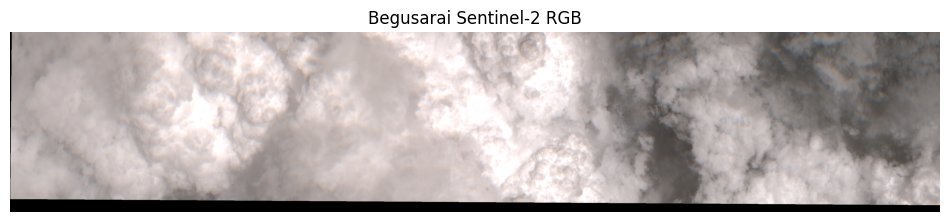

In [92]:
rgb = np.dstack([
    blue,
    green,
    red
])

# Normalize for visualization only
rgb_display = np.zeros_like(rgb, dtype=np.float32)

for i in range(3):
    band = rgb[:, :, i]
    p2, p98 = np.percentile(band, (2, 98))
    rgb_display[:, :, i] = np.clip(
        (band - p2) / (p98 - p2),
        0,
        1
    )

plt.figure(figsize=(12, 7))
plt.imshow(rgb_display)
plt.title("Begusarai Sentinel-2 RGB")
plt.axis("off")
plt.show()

In [93]:
PATCH_SIZE = 64
MIN_CLEAR_RATIO = 0.8

def extract_patches(features, clear_mask,
                     patch_size=64,
                     min_clear_ratio=0.8):

    patches = []

    height, width, channels = features.shape

    for row in range(0, height - patch_size + 1, patch_size):
        for col in range(0, width - patch_size + 1, patch_size):

            patch = features[
                row:row + patch_size,
                col:col + patch_size,
                :
            ]

            mask_patch = clear_mask[
                row:row + patch_size,
                col:col + patch_size
            ]

            clear_ratio = np.mean(mask_patch)

            # Keep only sufficiently clear patches
            if clear_ratio >= min_clear_ratio:

                patches.append(patch)

    if len(patches) == 0:
        return np.empty(
            (0, patch_size, patch_size, channels),
            dtype=np.float32
        )

    return np.array(patches, dtype=np.float32)

In [94]:
print("Patch extraction function is ready.")

Patch extraction function is ready.


In [95]:
#sentinel1
import os
import glob

s1_root = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1"

print("Searching for Sentinel-1 data...")

files = glob.glob(
    os.path.join(s1_root, "**", "*"),
    recursive=True
)

for f in files:
    print(f)

Searching for Sentinel-1 data...
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_95A8.SAFE-report-20260714T034627.pdf
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/support
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/preview
./drive/MyDrive/soa_idea

In [96]:
matches = glob.glob(
    "./drive/MyDrive/soa_ideathon_s6/**/*S1*",
    recursive=True
)

print("Sentinel-1 files found:", len(matches))

for f in matches[:100]:
    print(f)

Sentinel-1 files found: 6
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_95A8.SAFE-report-20260714T034627.pdf
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/S1_quality_an.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/S1_quality_ao.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/S1_radiance_an.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T1

In [97]:
import os

s1_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE"

print("Sentinel-1 product:")
print(s1_path)

print("\nContents:")
for item in os.listdir(s1_path):
    print(item)

Sentinel-1 product:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE

Contents:
S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_95A8.SAFE-report-20260714T034627.pdf
support
annotation
measurement
preview
manifest.safe


In [98]:
measurement_dir = os.path.join(s1_path, "measurement")

print("Measurement files:\n")

for file in os.listdir(measurement_dir):
    print(file)

Measurement files:

s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff
s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.tiff


In [100]:
import os

print("VV exists:", os.path.exists(vv_path))
print("VV size:", os.path.getsize(vv_path) / (1024 * 1024), "MB")

print("VH exists:", os.path.exists(vh_path))
print("VH size:", os.path.getsize(vh_path) / (1024 * 1024), "MB")

VV exists: True
VV size: 0.0 MB
VH exists: True
VH size: 547.9115839004517 MB


In [101]:
with open(vv_path, "rb") as f:
    header = f.read(16)

print("VV header:", header)

VV header: b''


In [102]:
with open(vh_path, "rb") as f:
    header = f.read(16)

print("VH header:", header)

VH header: b'II*\x00\xc0\x00\x00\x00GDAL_STR'


In [103]:
with open(vh_path, "rb") as f:
    header = f.read(16)

print("VH header:", header)

VH header: b'II*\x00\xc0\x00\x00\x00GDAL_STR'


In [104]:
with rasterio.open(vh_path) as src:
    print("VH opened successfully!")
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)

VH opened successfully!
Shape: (16747, 25521)
CRS: None
Resolution: (1.0, 1.0)
Bounds: BoundingBox(left=0.0, bottom=16747.0, right=25521.0, top=0.0)
Dtype: uint16
NoData: 0.0


In [105]:
annotation_dir = os.path.join(s1_path, "annotation")

print("Annotation files:\n")

for root, dirs, files in os.walk(annotation_dir):
    for file in files:
        print(os.path.join(root, file))

Annotation files:

./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.xml
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.xml
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/rfi/rfi-s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.xml
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/rfi/rfi-s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.xml
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_2026071

In [106]:
from osgeo import gdal

dataset = gdal.Open(vh_path)

if dataset is None:
    print("GDAL could not open VH")
else:
    print("GDAL opened VH successfully")

    print("\nRaster size:")
    print(dataset.RasterXSize, dataset.RasterYSize)

    print("\nProjection:")
    print(dataset.GetProjection())

    print("\nGeoTransform:")
    print(dataset.GetGeoTransform())

    print("\nMetadata:")
    metadata = dataset.GetMetadata()

    for key, value in metadata.items():
        print(key, "=", value)

GDAL opened VH successfully

Raster size:
25521 16747

Projection:


GeoTransform:
(0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Metadata:
AREA_OR_POINT = Area
GRD_ORIGINAL_FOOTER_SIZE = 70147
GRD_ORIGINAL_HEADER_SIZE = 382
TIFFTAG_DATETIME = 2026:07:14 03:45:36
TIFFTAG_IMAGEDESCRIPTION = Sentinel-1A IW GRD HR L1
TIFFTAG_SOFTWARE = Sentinel-1 IPF 004.03


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [107]:
import shutil

snap = shutil.which("gpt")

if snap:
    print("SNAP found:")
    print(snap)
else:
    print("SNAP not found")

SNAP not found


In [108]:
print("VV path:")
print(vv_path)

print("\nVV exists:", os.path.exists(vv_path))

if os.path.exists(vv_path):
    print("VV size:",
          os.path.getsize(vv_path) / (1024 * 1024),
          "MB")

VV path:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff

VV exists: True
VV size: 0.0 MB


In [109]:
!ls -lh "$vv_path"

-rw------- 1 root root 0 Aug 20 02:35 ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff


In [110]:
manifest_path = os.path.join(
    s1_path,
    "manifest.safe"
)

print("Manifest exists:", os.path.exists(manifest_path))
print("Manifest size:",
      os.path.getsize(manifest_path) / 1024,
      "KB")

Manifest exists: True
Manifest size: 24.7109375 KB


In [111]:
# Check polarization references in Sentinel-1 manifest

with open(manifest_path, "r", errors="ignore") as f:
    manifest_text = f.read()

print("VV references:", manifest_text.lower().count("vv"))
print("VH references:", manifest_text.lower().count("vh"))

print("\nVV mentioned:", "vv" in manifest_text.lower())
print("VH mentioned:", "vh" in manifest_text.lower())

VV references: 28
VH references: 28

VV mentioned: True
VH mentioned: True


In [112]:
import os

vv_path = os.path.join(
    s1_path,
    "measurement",
    "s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff"
)

vh_path = os.path.join(
    s1_path,
    "measurement",
    "s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.tiff"
)

print("VV path:")
print(vv_path)

print("\nVV:")
print("Exists:", os.path.exists(vv_path))
print("Size:", os.path.getsize(vv_path), "bytes")

print("\nVH:")
print("Exists:", os.path.exists(vh_path))
print("Size:", os.path.getsize(vh_path), "bytes")

VV path:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff

VV:
Exists: True
Size: 0 bytes

VH:
Exists: True
Size: 574526937 bytes


In [113]:
import rasterio
import numpy as np

with rasterio.open(vh_path) as src:
    vh = src.read(1)

print("VH loaded successfully")
print("Shape:", vh.shape)
print("Dtype:", vh.dtype)

print("\nStatistics:")
print("Min:", np.min(vh))
print("Max:", np.max(vh))
print("Mean:", np.mean(vh))
print("Median:", np.median(vh))

print("\nZero pixels:", np.sum(vh == 0))
print("Total pixels:", vh.size)
print("Valid pixels:", np.sum(vh > 0))

VH loaded successfully
Shape: (16747, 25521)
Dtype: uint16

Statistics:
Min: 0
Max: 7626
Mean: 104.55999926364095
Median: 102.0

Zero pixels: 6268179
Total pixels: 427400187
Valid pixels: 421132008


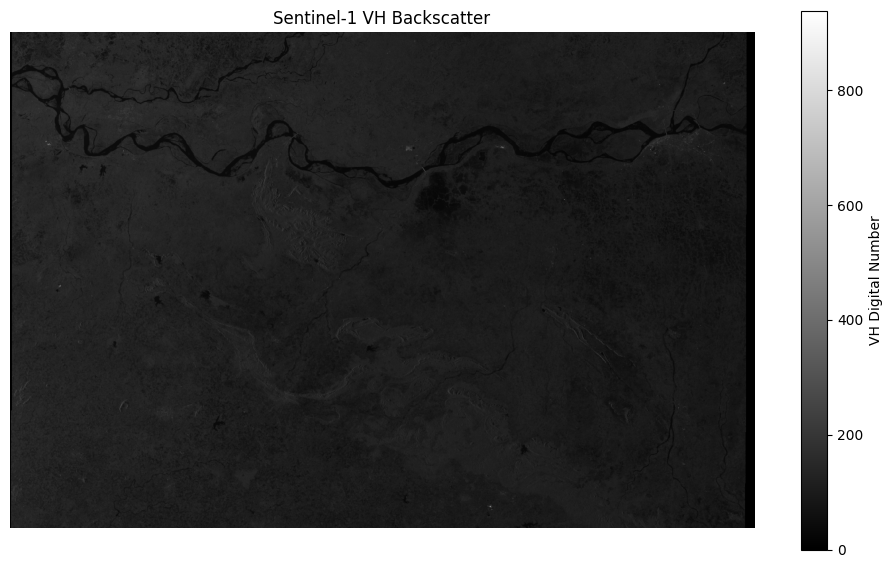

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Display a downsampled VH image
with rasterio.open(vh_path) as src:
    vh_sample = src.read(
        1,
        out_shape=(1, 1000, 1500)
    )

plt.figure(figsize=(12, 7))

plt.imshow(
    vh_sample,
    cmap="gray"
)

plt.title("Sentinel-1 VH Backscatter")
plt.axis("off")
plt.colorbar(label="VH Digital Number")

plt.show()

In [115]:
import xml.etree.ElementTree as ET

vh_xml = os.path.join(
    s1_path,
    "annotation",
    "s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.xml"
)

print("XML exists:", os.path.exists(vh_xml))

tree = ET.parse(vh_xml)
root = tree.getroot()

print("XML loaded successfully")
print("Root:", root.tag)

XML exists: True
XML loaded successfully
Root: product


In [116]:
# Find geographic coordinate-related elements

for elem in root.iter():
    tag = elem.tag.lower()

    if any(x in tag for x in ["geolocation", "latitude", "longitude"]):
        print(elem.tag, "=", elem.text)

geolocationGrid = 
    
geolocationGridPointList = 
      
geolocationGridPoint = 
        
latitude = 2.555671170963071e+01
longitude = 8.746982260654757e+01
geolocationGridPoint = 
        
latitude = 2.557859155785426e+01
longitude = 8.734514727689452e+01
geolocationGridPoint = 
        
latitude = 2.560036525135938e+01
longitude = 8.722042671706981e+01
geolocationGridPoint = 
        
latitude = 2.562203269629298e+01
longitude = 8.709566110007569e+01
geolocationGridPoint = 
        
latitude = 2.564359370448887e+01
longitude = 8.697085057983877e+01
geolocationGridPoint = 
        
latitude = 2.566504820217586e+01
longitude = 8.684599533520860e+01
geolocationGridPoint = 
        
latitude = 2.568639597395377e+01
longitude = 8.672109551568265e+01
geolocationGridPoint = 
        
latitude = 2.570763694726067e+01
longitude = 8.659615130144718e+01
geolocationGridPoint = 
        
latitude = 2.572877091738329e+01
longitude = 8.647116284575199e+01
geolocationGridPoint = 
        
latitude

In [117]:
import xml.etree.ElementTree as ET

vh_xml = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.xml"

tree = ET.parse(vh_xml)
root = tree.getroot()

gcps = []

for point in root.iter():
    # Remove namespace if present
    tag = point.tag.split("}")[-1]

    if tag == "geolocationGridPoint":
        values = {}

        for child in point:
            child_tag = child.tag.split("}")[-1]
            values[child_tag] = child.text

        if all(k in values for k in ["line", "pixel", "latitude", "longitude"]):
            gcps.append({
                "line": int(values["line"]),
                "pixel": int(values["pixel"]),
                "lat": float(values["latitude"]),
                "lon": float(values["longitude"])
            })

print("GCPs found:", len(gcps))
print("\nFirst 5 GCPs:")

for gcp in gcps[:5]:
    print(gcp)

GCPs found: 210

First 5 GCPs:
{'line': 0, 'pixel': 0, 'lat': 25.55671170963071, 'lon': 87.46982260654757}
{'line': 0, 'pixel': 1276, 'lat': 25.57859155785426, 'lon': 87.34514727689452}
{'line': 0, 'pixel': 2552, 'lat': 25.60036525135938, 'lon': 87.22042671706981}
{'line': 0, 'pixel': 3828, 'lat': 25.62203269629298, 'lon': 87.09566110007569}
{'line': 0, 'pixel': 5104, 'lat': 25.64359370448887, 'lon': 86.97085057983877}


In [119]:
from osgeo import gdal, osr

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.tiff"

output_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif"

# Open original VH
src = gdal.Open(vh_path, gdal.GA_ReadOnly)

print("Source opened:", src is not None)
print("Size:", src.RasterXSize, src.RasterYSize)

# Create GCPs
gdal_gcps = []

for gcp in gcps:
    g = gdal.GCP(
        float(gcp["lon"]),      # X = longitude
        float(gcp["lat"]),      # Y = latitude
        0,
        float(gcp["pixel"]),    # pixel
        float(gcp["line"])      # line
    )
    gdal_gcps.append(g)

print("GCPs:", len(gdal_gcps))

# WGS84
srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)

# Assign GCPs to source
src.SetGCPs(gdal_gcps, srs.ExportToWkt())

# Create temporary GCP file
gcp_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_with_GCPs.tif"

gdal.Translate(
    gcp_path,
    src,
    format="GTiff"
)

print("GCP file created:", gcp_path)

src = None

Source opened: True
Size: 25521 16747


KeyError: 'lon'

In [120]:
from osgeo import gdal, osr
import xml.etree.ElementTree as ET
import os

# --------------------------------------------------
# Paths
# --------------------------------------------------

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.tiff"

vh_xml = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/annotation/s1d-iw-grd-vh-20260714t001125-20260714t001150-003662-00689f-002-cog.xml"

output_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif"

# --------------------------------------------------
# 1. Read VH
# --------------------------------------------------

src = gdal.Open(vh_path, gdal.GA_ReadOnly)

print("Source opened:", src is not None)
print("Size:", src.RasterXSize, src.RasterYSize)

# --------------------------------------------------
# 2. Re-extract GCPs
# --------------------------------------------------

tree = ET.parse(vh_xml)
root = tree.getroot()

gcps_clean = []

for elem in root.iter():

    if elem.tag.split("}")[-1] != "geolocationGridPoint":
        continue

    data = {}

    for child in elem.iter():

        tag = child.tag.split("}")[-1]

        if child.text:
            text = child.text.strip()

            if tag in ["line", "pixel", "latitude", "longitude"]:
                data[tag] = text

    if all(k in data for k in ["line", "pixel", "latitude", "longitude"]):

        gcps_clean.append({
            "line": float(data["line"]),
            "pixel": float(data["pixel"]),
            "lat": float(data["latitude"]),
            "lon": float(data["longitude"])
        })

print("GCPs extracted:", len(gcps_clean))

# --------------------------------------------------
# 3. Show first GCP
# --------------------------------------------------

print("First GCP:")
print(gcps_clean[0])

# --------------------------------------------------
# 4. Convert to GDAL GCPs
# --------------------------------------------------

gdal_gcps = []

for gcp in gcps_clean:

    g = gdal.GCP(
        gcp["lon"],       # longitude
        gcp["lat"],       # latitude
        0,
        gcp["pixel"],     # pixel
        gcp["line"]       # line
    )

    gdal_gcps.append(g)

print("GDAL GCPs:", len(gdal_gcps))

# --------------------------------------------------
# 5. Set WGS84
# --------------------------------------------------

srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)

# --------------------------------------------------
# 6. Create temporary GCP GeoTIFF
# --------------------------------------------------

temp_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_with_GCPs.tif"

gdal.Translate(
    temp_path,
    src,
    format="GTiff"
)

src = None

# --------------------------------------------------
# 7. Reopen and attach GCPs
# --------------------------------------------------

gcp_ds = gdal.Open(temp_path, gdal.GA_Update)

gcp_ds.SetGCPs(
    gdal_gcps,
    srs.ExportToWkt()
)

gcp_ds.FlushCache()
gcp_ds = None

print("GCPs successfully attached.")

# --------------------------------------------------
# 8. Georeference using Thin Plate Spline
# --------------------------------------------------

result = gdal.Warp(
    output_path,
    temp_path,
    dstSRS="EPSG:4326",
    tps=True,
    resampleAlg="bilinear",
    format="GTiff"
)

if result is not None:

    print("\nSUCCESS!")
    print("Output:", output_path)
    print("Size:", result.RasterXSize, result.RasterYSize)

    result = None

else:

    print("ERROR: GDAL Warp failed.")

Source opened: True
Size: 25521 16747
GCPs extracted: 210
First GCP:
{'line': 0.0, 'pixel': 0.0, 'lat': 25.55671170963071, 'lon': 87.46982260654757}
GDAL GCPs: 210
GCPs successfully attached.

SUCCESS!
Output: ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif
Size: 28450 19579


In [121]:
from osgeo import gdal, osr

temp_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_with_GCPs.tif"

# Open original VH
src = gdal.Open(vh_path, gdal.GA_ReadOnly)

# Create temporary TIFF
gdal.Translate(
    temp_path,
    src,
    format="GTiff"
)

src = None

print("Temporary TIFF created.")

# Open for updating
gcp_ds = gdal.Open(temp_path, gdal.GA_Update)

print("Temporary TIFF opened:", gcp_ds is not None)

# WGS84
srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)

# Attach GCPs
gcp_ds.SetGCPs(
    gdal_gcps,
    srs.ExportToWkt()
)

gcp_ds.FlushCache()
gcp_ds = None

print("GCPs attached successfully!")

Temporary TIFF created.
Temporary TIFF opened: True
GCPs attached successfully!


In [122]:
ds = gdal.Open(temp_path)

print("GCP count:", ds.GetGCPCount())
print("GCP projection:", ds.GetGCPProjection()[:100])

ds = None

GCP count: 210
GCP projection: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],A


In [123]:
from osgeo import gdal

georef_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif"

print("Starting georeferencing...")
print("This may take a few minutes because the image is 25,521 × 16,747 pixels.")

result = gdal.Warp(
    georef_path,
    temp_path,
    dstSRS="EPSG:4326",
    tps=True,
    resampleAlg="bilinear",
    format="GTiff",
    creationOptions=[
        "COMPRESS=LZW",
        "TILED=YES"
    ]
)

if result is not None:
    print("\nSUCCESS!")
    print("File:", georef_path)
    print("Size:", result.RasterXSize, "x", result.RasterYSize)
    result = None
else:
    print("Georeferencing failed.")


Starting georeferencing...
This may take a few minutes because the image is 25,521 × 16,747 pixels.

SUCCESS!
File: ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif
Size: 28450 x 19579


In [124]:
from osgeo import gdal

georef_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif"

ds = gdal.Open(georef_path)

print("Opened:", ds is not None)
print("Size:", ds.RasterXSize, ds.RasterYSize)
print("Projection:", ds.GetProjection())
print("GeoTransform:", ds.GetGeoTransform())
print("Bounds:")

gt = ds.GetGeoTransform()
width = ds.RasterXSize
height = ds.RasterYSize

left = gt[0]
top = gt[3]
right = left + width * gt[1]
bottom = top + height * gt[5]

print("Left:", left)
print("Right:", right)
print("Top:", top)
print("Bottom:", bottom)

ds = None

Opened: True
Size: 28450 19579
Projection: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
GeoTransform: (84.6712972036747, 9.836630563105505e-05, 0.0, 25.9740462737346, 0.0, -9.836630563105505e-05)
Bounds:
Left: 84.6712972036747
Right: 87.46981859887822
Top: 25.9740462737346
Bottom: 24.048132375784174


In [125]:
import rasterio
from rasterio.windows import from_bounds

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_georeferenced.tif"

# Begusarai approximate bounding box
min_lon = 86.0
max_lon = 87.0
min_lat = 25.0
max_lat = 25.7

with rasterio.open(vh_path) as src:

    window = from_bounds(
        min_lon, min_lat,
        max_lon, max_lat,
        src.transform
    )

    data = src.read(1, window=window)

    profile = src.profile.copy()
    profile.update({
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": src.window_transform(window)
    })

    output = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif"

    with rasterio.open(output, "w", **profile) as dst:
        dst.write(data, 1)

print("SUCCESS!")
print("Output:", output)
print("Shape:", data.shape)


SUCCESS!
Output: ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif
Shape: (7116, 10166)


Shape: (7116, 10166)
Min: 0
Max: 1945
Mean: 117.75335711616619


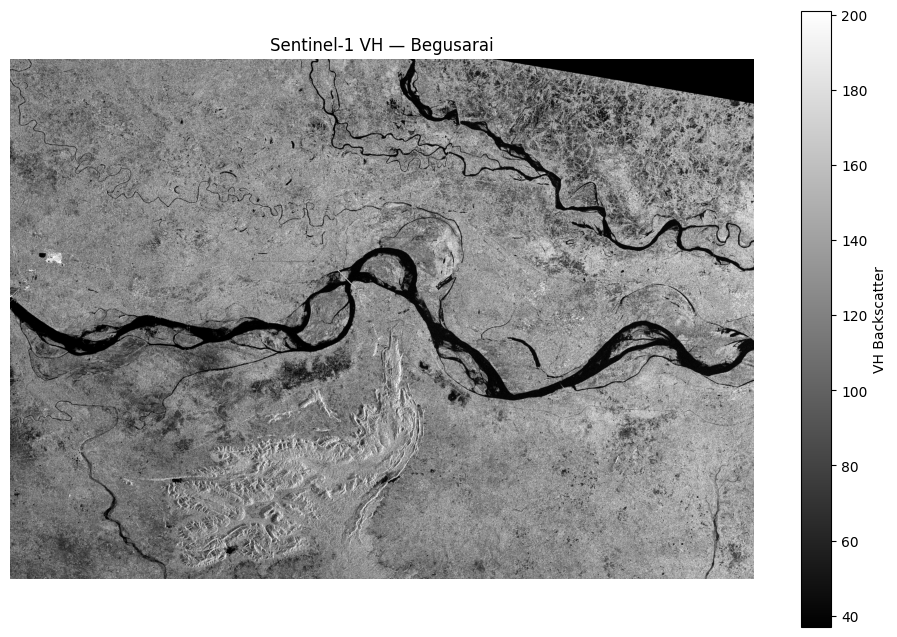

In [126]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

vh_crop = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif"

with rasterio.open(vh_crop) as src:
    vh = src.read(1)

print("Shape:", vh.shape)
print("Min:", vh.min())
print("Max:", vh.max())
print("Mean:", vh.mean())

# Remove zero/no-data pixels for visualization
valid = vh[vh > 0]

vmin = np.percentile(valid, 2)
vmax = np.percentile(valid, 98)

plt.figure(figsize=(12, 8))
plt.imshow(vh, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Sentinel-1 VH — Begusarai")
plt.axis("off")
plt.colorbar(label="VH Backscatter")
plt.show()

In [127]:
import os

vv_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/S1D_IW_GRDH_1SDV_20260714T001125_20260714T001150_003662_00689F_AEA9_COG.SAFE/measurement/s1d-iw-grd-vv-20260714t001125-20260714t001150-003662-00689f-001-cog.tiff"

print("Exists:", os.path.exists(vv_path))
print("Size:", os.path.getsize(vv_path), "bytes")

with open(vv_path, "rb") as f:
    print("Header:", f.read(16))

Exists: True
Size: 0 bytes
Header: b''


In [128]:
import rasterio
import numpy as np

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif"

with rasterio.open(vh_path) as src:
    vh = src.read(1).astype(np.float32)

print("Original:")
print("Shape:", vh.shape)
print("Min:", vh.min())
print("Max:", vh.max())
print("Mean:", vh.mean())

# Valid pixels
valid = vh > 0

# Percentile-based clipping
low = np.percentile(vh[valid], 2)
high = np.percentile(vh[valid], 98)

print("\nClipping:")
print("2nd percentile:", low)
print("98th percentile:", high)

# Clip
vh_clipped = np.clip(vh, low, high)

# Normalize to 0-1
vh_norm = np.zeros_like(vh_clipped)

vh_norm[valid] = (
    (vh_clipped[valid] - low) /
    (high - low)
)

print("\nNormalized:")
print("Min:", vh_norm[valid].min())
print("Max:", vh_norm[valid].max())
print("Mean:", vh_norm[valid].mean())
print("Valid pixels:", valid.sum())

Original:
Shape: (7116, 10166)
Min: 0.0
Max: 1945.0
Mean: 117.75342

Clipping:
2nd percentile: 37.0
98th percentile: 201.0

Normalized:
Min: 0.0
Max: 1.0
Mean: 0.50170463
Valid pixels: 71204960


In [129]:
import rasterio
import numpy as np

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif"

with rasterio.open(vh_path) as src:
    vh = src.read(1).astype(np.float32)

# Valid pixels only
valid = vh > 0
valid_values = vh[valid]

# Calculate percentiles
p2 = np.percentile(valid_values, 2)
p98 = np.percentile(valid_values, 98)

print("Valid pixels:", valid_values.size)
print("2nd percentile:", p2)
print("98th percentile:", p98)

# Clip extreme values
vh_clip = np.clip(vh, p2, p98)

# Normalize to 0-1
vh_norm = np.zeros_like(vh_clip)

vh_norm[valid] = (
    (vh_clip[valid] - p2) / (p98 - p2)
)

print("\nNormalized VH:")
print("Min:", vh_norm[valid].min())
print("Max:", vh_norm[valid].max())
print("Mean:", vh_norm[valid].mean())

Valid pixels: 71204960
2nd percentile: 37.0
98th percentile: 201.0

Normalized VH:
Min: 0.0
Max: 1.0
Mean: 0.50170463


In [130]:
import rasterio
import numpy as np

vh_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai.tif"

output_path = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai_normalized.tif"

with rasterio.open(vh_path) as src:
    vh = src.read(1).astype(np.float32)
    profile = src.profile.copy()

valid = vh > 0

p2 = 37.0
p98 = 201.0

vh_clip = np.clip(vh, p2, p98)

vh_norm = np.zeros_like(vh_clip, dtype=np.float32)

vh_norm[valid] = (
    (vh_clip[valid] - p2) / (p98 - p2)
)

profile.update(
    dtype="float32",
    nodata=0.0,
    compress="deflate"
)

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(vh_norm, 1)

print("SUCCESS!")
print("Saved:", output_path)
print("Shape:", vh_norm.shape)
print("Valid pixels:", valid.sum())
print("Normalized range:",
      vh_norm[valid].min(),
      vh_norm[valid].max())

SUCCESS!
Saved: ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel1/VH_Begusarai_normalized.tif
Shape: (7116, 10166)
Valid pixels: 71204960
Normalized range: 0.0 1.0


In [35]:
BASE = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai"
S2_DIR = f"{BASE}/sentinel2"

print(S2_DIR)

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2


In [36]:
import os

for root, dirs, files in os.walk(S2_DIR):
    level = root.replace(S2_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

sentinel2/
  target_districts.geojson
  download_begusarai_missing_tiles.py
  S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/
    INSPIRE.xml
    MTD_MSIL2A.xml
    S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809-ql.jpg
    manifest.safe
    GRANULE/
    HTML/
      banner_2.png
      UserProduct_index.html
      banner_3.png
      star_bg.jpg
      banner_1.png
      UserProduct_index.xsl
    DATASTRIP/
    rep_info/
      S2_PDI_Level-2A_Datastrip_Metadata.xsd
      S2_User_Product_Level-2A_Metadata.xsd
      S2_PDI_Level-2A_Tile_Metadata.xsd


In [37]:
from pathlib import Path

s2_files = list(Path(S2_DIR).rglob("*"))

print("Total files:", len(s2_files))

for f in s2_files:
    if f.suffix.lower() in [".jp2", ".tif", ".tiff"]:
        print(f)

Total files: 111
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B11.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_QUALIT_B01.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_DETFOO_B12.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MSK_DETFOO_B08.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE/GRANULE/L2A_T45RUH_A009627_20260710T045042/QI_DATA/MS

In [38]:
from pathlib import Path
import re

S2_DIR = Path("/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2")

tiles = {}

for f in S2_DIR.rglob("*.SAFE"):
    match = re.search(r"_T(\d{2}[A-Z]{3})_", f.name)
    if match:
        tile = "T" + match.group(1)
        tiles[tile] = f

print("Sentinel-2 tiles found:")
for tile, path in sorted(tiles.items()):
    print(f"{tile} -> {path}")

print("\nNumber of tiles:", len(tiles))

Sentinel-2 tiles found:
T45RUH -> /content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE

Number of tiles: 1


In [39]:
import rasterio
import geopandas as gpd
from pathlib import Path

S2_DIR = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2"
)

safe_path = next(S2_DIR.glob("*.SAFE"))
b04 = next(safe_path.rglob("*_B04_10m.jp2"))

with rasterio.open(b04) as src:
    print("Tile:", safe_path.name)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)

Tile: S2C_MSIL2A_20260710T044701_N0512_R076_T45RUH_20260710T095809.SAFE
CRS: EPSG:32645
Bounds: BoundingBox(left=300000.0, bottom=2690220.0, right=409800.0, top=2800020.0)
Resolution: (10.0, 10.0)


In [40]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai")

print("GeoJSON files found:\n")

for f in BASE.rglob("*.geojson"):
    print(f)

GeoJSON files found:

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson


In [41]:
import geopandas as gpd

GEOJSON = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson"

gdf = gpd.read_file(GEOJSON)

print("CRS:", gdf.crs)
print("Number of features:", len(gdf))
print("\nColumns:")
print(gdf.columns.tolist())

print("\nDistrict names:")
for col in gdf.columns:
    if "name" in col.lower() or "district" in col.lower():
        print(col, gdf[col].unique())


CRS: EPSG:4326
Number of features: 3

Columns:
['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']

District names:
NAME_1 ['Bihar']
NL_NAME_1 ['NA']
NAME_2 ['Begusarai' 'Gaya' 'Katihar']
VARNAME_2 ['NA' 'Kathihar']
NL_NAME_2 ['NA']


In [42]:
gdf_utm = gdf.to_crs("EPSG:32645")

print("Reprojected CRS:", gdf_utm.crs)
print("Bounds:", gdf_utm.total_bounds)

Reprojected CRS: EPSG:32645
Bounds: [ 224819.98262462 2688291.9840767   607824.28849116 2862806.3474327 ]


In [43]:
from shapely.geometry import box
import rasterio

safe_path = next(S2_DIR.glob("*.SAFE"))
b04 = next(safe_path.rglob("*_B04_10m.jp2"))

with rasterio.open(b04) as src:
    tile_bounds = box(*src.bounds)

begusarai = gdf_utm.geometry.unary_union

print("Tile intersects Begusarai:", tile_bounds.intersects(begusarai))
print("Begusarai completely inside tile:", tile_bounds.contains(begusarai))

Tile intersects Begusarai: True
Begusarai completely inside tile: False


/tmp/ipykernel_2832/702268412.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  begusarai = gdf_utm.geometry.unary_union


In [44]:
from shapely.geometry import box
import geopandas as gpd

# Begusarai boundary
GEOJSON = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson"

gdf = gpd.read_file(GEOJSON).to_crs("EPSG:32645")

begusarai = gdf.geometry.union_all()

# Sentinel-2 UTM tile footprints around the area
# These are approximate UTM tile extents and are only being used
# to identify which neighboring MGRS tiles are needed.

tile_bounds = {
    "T45RUH": (300000, 2690220, 409800, 2800020),
}

for tile, bounds in tile_bounds.items():
    tile_geom = box(*bounds)

    intersection = tile_geom.intersection(begusarai)

    if not intersection.is_empty:
        print(tile, "intersects Begusarai")
        print("Intersection area:", intersection.area)

T45RUH intersects Begusarai
Intersection area: 1975080317.7065356


In [45]:
# Use the newer GeoPandas method to avoid the warning
begusarai = gdf.geometry.union_all()

# T45RUH footprint
tile_geom = box(
    300000.0,
    2690220.0,
    409800.0,
    2800020.0
)

# Part of Begusarai that lies outside T45RUH
outside = begusarai.difference(tile_geom)

print("Begusarai total area:", begusarai.area)
print("Area inside T45RUH:", begusarai.intersection(tile_geom).area)
print("Area outside T45RUH:", outside.area)

print("\nBegusarai bounds:")
print(begusarai.bounds)

print("\nT45RUH bounds:")
print(tile_geom.bounds)

Begusarai total area: 9966439591.718386
Area inside T45RUH: 1975080317.7065375
Area outside T45RUH: 7991359274.011848

Begusarai bounds:
(224819.9826246192, 2688291.9840766964, 607824.2884911591, 2862806.3474327)

T45RUH bounds:
(300000.0, 2690220.0, 409800.0, 2800020.0)


In [46]:
inside_area = begusarai.intersection(tile_geom).area
total_area = begusarai.area

print(
    f"T45RUH covers approximately "
    f"{inside_area / total_area * 100:.2f}% of Begusarai"
)

print(
    f"Missing coverage is approximately "
    f"{100 - inside_area / total_area * 100:.2f}%"
)

T45RUH covers approximately 19.82% of Begusarai
Missing coverage is approximately 80.18%


In [2]:
#heatwave
import os

base = "./drive/MyDrive/soa_ideathon_s6/data"

for root, dirs, files in os.walk(base):
    for f in files:
        if any(x in f.lower() for x in [
            "temp", "temperature", "heat", "lst",
            "land_surface", "era5", "imd", "heatwave"
        ]):
            print(os.path.join(root, f))

In [4]:
import os

s3_dir = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3"

for root, dirs, files in os.walk(s3_dir):
    for f in files:
        print(os.path.join(root, f))

./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_an.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_bn.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_in.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_bo.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/F2_quality_io.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0

In [5]:
import xarray as xr
import os

s3_dir = "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3"

for fname in ["S7_BT_in.nc", "S8_BT_in.nc", "S9_BT_in.nc"]:

    path = os.path.join(
        s3_dir,
        "S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3",
        fname
    )

    print("\n" + "="*60)
    print(fname)

    ds = xr.open_dataset(path)

    print(ds)
    print("\nVariables:")
    for var in ds.data_vars:
        print(
            var,
            "shape =", ds[var].shape,
            "dtype =", ds[var].dtype,
            "units =", ds[var].attrs.get("units")
        )

    ds.close()


S7_BT_in.nc
<xarray.Dataset> Size: 18MB
Dimensions:                 (rows: 1200, columns: 1500, orphan_pixels: 187)
Dimensions without coordinates: rows, columns, orphan_pixels
Data variables:
    S7_BT_in                (rows, columns) float64 14MB ...
    S7_BT_orphan_in         (rows, orphan_pixels) float64 2MB ...
    S7_exception_in         (rows, columns) uint8 2MB ...
    S7_exception_orphan_in  (rows, orphan_pixels) uint8 224kB ...
Attributes: (12/17)
    absolute_orbit_number:  42805
    comment:                 
    contact:                eosupport@copernicus.esa.int
    creation_time:          20260716T001340Z
    history:                  2026-07-16T00:13:40Z: PUGCoreProcessor /data/WO...
    institution:            ESA
    ...                     ...
    source:                 IPF-SL-1 06.24
    start_offset:           42816
    start_time:             2026-07-14T16:26:04.637750Z
    stop_time:              2026-07-14T16:29:04.331411Z
    title:                  S3 SLST

In [6]:
import xarray as xr
import os
import numpy as np

s3_product = (
    "./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/"
    "S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3"
)

for band in ["S7", "S8", "S9"]:
    path = os.path.join(s3_product, f"{band}_BT_in.nc")

    ds = xr.open_dataset(path)
    bt = ds[f"{band}_BT_in"].values

    valid = bt[np.isfinite(bt)]

    print("=" * 50)
    print(band)
    print("Min:", np.min(valid))
    print("Max:", np.max(valid))
    print("Mean:", np.mean(valid))
    print("Median:", np.median(valid))
    print("5th percentile:", np.percentile(valid, 5))
    print("95th percentile:", np.percentile(valid, 95))

    ds.close()

S7
Min: 168.76000000000002
Max: 304.99
Mean: 279.65659458326917
Median: 283.69
5th percentile: 244.18
95th percentile: 298.51
S8
Min: 183.89000000000001
Max: 299.17
Mean: 273.6651396262235
Median: 276.53000000000003
5th percentile: 234.05
95th percentile: 295.85
S9
Min: 182.87
Max: 296.71000000000004
Mean: 271.15028206750395
Median: 274.28000000000003
5th percentile: 232.21
95th percentile: 293.48


In [7]:
for band in ["S7", "S8", "S9"]:
    path = os.path.join(s3_product, f"{band}_BT_in.nc")

    ds = xr.open_dataset(path)
    exc = ds[f"{band}_exception_in"].values

    unique, counts = np.unique(exc, return_counts=True)

    print("\n", band, "exception flags:")
    for u, c in zip(unique, counts):
        print(f"  {u}: {c} pixels")

    ds.close()


 S7 exception flags:
  0: 1357932 pixels
  2: 350737 pixels
  128: 91331 pixels

 S8 exception flags:
  0: 1357932 pixels
  2: 350737 pixels
  128: 91331 pixels

 S9 exception flags:
  0: 1357932 pixels
  2: 350737 pixels
  128: 91331 pixels


In [8]:
import xarray as xr
import os

path = os.path.join(
    s3_product,
    "S7_BT_in.nc"
)

ds = xr.open_dataset(path)

print(ds.attrs)

print("\nS7 exception attributes:")
print(ds["S7_exception_in"].attrs)

ds.close()

{'absolute_orbit_number': np.uint32(42805), 'comment': ' ', 'contact': 'eosupport@copernicus.esa.int', 'creation_time': '20260716T001340Z', 'history': '  2026-07-16T00:13:40Z: PUGCoreProcessor /data/WORK/PUG_S3B_SL_1_RBT-03.51/100039639/JobOrder.100039639.xml', 'institution': 'ESA', 'netCDF_version': '4.2 of Mar 13 2018 10:14:33 $', 'processing_baseline': 'SL__L1_.005.00.00', 'product_name': 'S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3', 'references': 'S3IPF PDS 005.1 - i2r12 - Product Data Format Specification - SLSTR Level 1, S3IPF PDS 002 - i1r8 - Product Data Format Specification - Product Structures, S3IPF DPM 003 - i1r13 - Detailed Processing Model - SLSTR Level 1', 'resolution': '[ 1000 1000 ]', 'source': 'IPF-SL-1 06.24', 'start_offset': np.int32(42816), 'start_time': '2026-07-14T16:26:04.637750Z', 'stop_time': '2026-07-14T16:29:04.331411Z', 'title': 'S3 SLSTR L1 Radiance and Brightness Temperatures Product. (Measurements 

In [9]:
import numpy as np
import xarray as xr
import os

path = os.path.join(s3_product, "S7_BT_in.nc")

ds = xr.open_dataset(path)

bt = ds["S7_BT_in"].values
exception = ds["S7_exception_in"].values

# Keep only clean pixels
valid = (exception == 0) & np.isfinite(bt)

bt_valid = bt[valid]

print("Total pixels:", bt.size)
print("Clean pixels:", valid.sum())
print("Usable percentage:", valid.sum() / bt.size * 100)

print("\nBrightness Temperature:")
print("Min:", bt_valid.min(), "K")
print("Max:", bt_valid.max(), "K")
print("Mean:", bt_valid.mean(), "K")
print("Median:", np.median(bt_valid), "K")

# Convert to Celsius
temp_c = bt_valid - 273.15

print("\nTemperature:")
print("Min:", temp_c.min(), "°C")
print("Max:", temp_c.max(), "°C")
print("Mean:", temp_c.mean(), "°C")
print("Median:", np.median(temp_c), "°C")

ds.close()

Total pixels: 1800000
Clean pixels: 1357932
Usable percentage: 75.44066666666667

Brightness Temperature:
Min: 168.76000000000002 K
Max: 304.99 K
Mean: 280.95701629389396 K
Median: 285.65000000000003 K

Temperature:
Min: -104.38999999999996 °C
Max: 31.840000000000032 °C
Mean: 7.807016293893992 °C
Median: 12.500000000000057 °C


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Use bt_valid from the previous cell

percentiles = [1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99]

for p in percentiles:
    print(f"{p}th percentile: {np.percentile(bt_valid, p):.2f} K "
          f"({np.percentile(bt_valid, p)-273.15:.2f} °C)")

1th percentile: 222.49 K (-50.66 °C)
2th percentile: 230.59 K (-42.56 °C)
5th percentile: 247.80 K (-25.35 °C)
10th percentile: 258.25 K (-14.90 °C)
25th percentile: 271.39 K (-1.76 °C)
50th percentile: 285.65 K (12.50 °C)
75th percentile: 295.26 K (22.11 °C)
90th percentile: 297.72 K (24.57 °C)
95th percentile: 298.66 K (25.51 °C)
98th percentile: 299.57 K (26.42 °C)
99th percentile: 300.01 K (26.86 °C)


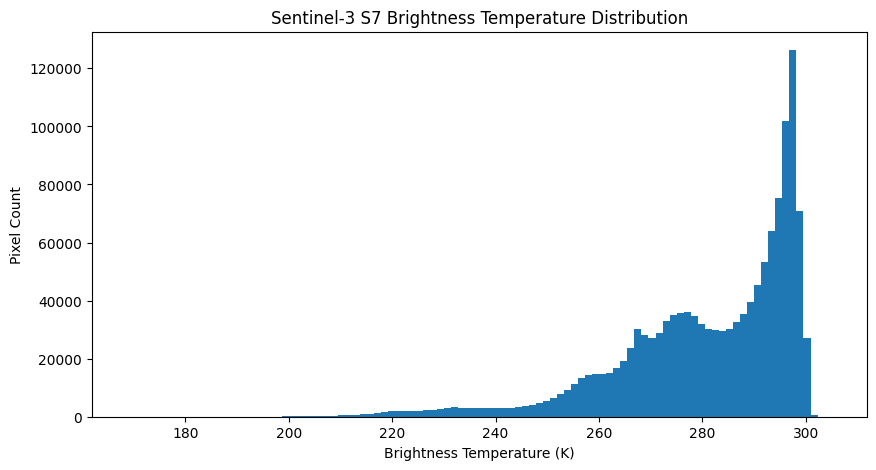

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    bt_valid,
    bins=100
)

plt.xlabel("Brightness Temperature (K)")
plt.ylabel("Pixel Count")
plt.title("Sentinel-3 S7 Brightness Temperature Distribution")

plt.show()

In [12]:
import os

print("Sentinel-3 product:")
print(s3_product)

print("\nFiles containing geolocation:")
for root, dirs, files in os.walk(s3_product):
    for f in files:
        if any(x in f.lower() for x in ["geo", "latitude", "longitude"]):
            print(os.path.join(root, f))

Sentinel-3 product:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3

Files containing geolocation:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_bn.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_an.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_ao.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_io.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905

In [13]:
import xarray as xr
import os

geo_path = os.path.join(s3_product, "geodetic_in.nc")

ds_geo = xr.open_dataset(geo_path)

print(ds_geo)

print("\nVariables:")
for var in ds_geo.data_vars:
    print(
        var,
        "shape =", ds_geo[var].shape,
        "dtype =", ds_geo[var].dtype,
        "units =", ds_geo[var].attrs.get("units")
    )

ds_geo.close()

<xarray.Dataset> Size: 48MB
Dimensions:              (rows: 1200, columns: 1500, orphan_pixels: 187)
Dimensions without coordinates: rows, columns, orphan_pixels
Data variables:
    elevation_in         (rows, columns) float64 14MB ...
    elevation_orphan_in  (rows, orphan_pixels) float32 898kB ...
    latitude_in          (rows, columns) float64 14MB ...
    latitude_orphan_in   (rows, orphan_pixels) float64 2MB ...
    longitude_in         (rows, columns) float64 14MB ...
    longitude_orphan_in  (rows, orphan_pixels) float64 2MB ...
Attributes: (12/17)
    absolute_orbit_number:  42805
    comment:                 
    contact:                eosupport@copernicus.esa.int
    creation_time:          20260716T001340Z
    history:                  2026-07-16T00:13:40Z: PUGCoreProcessor /data/WO...
    institution:            ESA
    ...                     ...
    source:                 IPF-SL-1 06.24
    start_offset:           42816
    start_time:             2026-07-14T16:26:04.6

In [15]:
import xarray as xr
import numpy as np

ds_geo = xr.open_dataset(geo_path)

lat = ds_geo["latitude_in"].values
lon = ds_geo["longitude_in"].values

print("Latitude range :", np.nanmin(lat), "to", np.nanmax(lat))
print("Longitude range:", np.nanmin(lon), "to", np.nanmax(lon))
print("Grid shape     :", lat.shape)

ds_geo.close()

Latitude range : 20.18369 to 33.508188
Longitude range: 72.53966199999999 to 89.878722
Grid shape     : (1200, 1500)


In [16]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".geojson"):
            print(os.path.join(root, file))

/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson


In [17]:
import geopandas as gpd

geojson_path = "/content/drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel2/target_districts.geojson"

gdf = gpd.read_file(geojson_path)

print(gdf)
print("\nColumns:")
print(gdf.columns)

print("\nCRS:")
print(gdf.crs)

print("\nBounds:")
print(gdf.total_bounds)

        GID_2 GID_0 COUNTRY    GID_1 NAME_1 NL_NAME_1     NAME_2 VARNAME_2  \
0   IND.5.5_1   IND   India  IND.5_1  Bihar        NA  Begusarai        NA   
1  IND.5.10_1   IND   India  IND.5_1  Bihar        NA       Gaya        NA   
2  IND.5.15_1   IND   India  IND.5_1  Bihar        NA    Katihar  Kathihar   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA  District  District   NA  IN.BR.BE   
1        NA  District  District   NA  IN.BR.GA   
2        NA  District  District   NA  IN.BR.KT   

                                            geometry  
0  MULTIPOLYGON (((86.3072 25.3169, 86.2918 25.29...  
1  MULTIPOLYGON (((84.7315 25.0579, 84.748 25.053...  
2  MULTIPOLYGON (((87.5474 25.3309, 87.5376 25.33...  

Columns:
Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')

CRS:
EPSG:4326

Bounds:
[84.2853 24.287  88.0729 25.8815]


In [18]:
begusarai = gdf[gdf["NAME_2"] == "Begusarai"].copy()

print(begusarai)
print("\nBegusarai bounds:")
print(begusarai.total_bounds)

       GID_2 GID_0 COUNTRY    GID_1 NAME_1 NL_NAME_1     NAME_2 VARNAME_2  \
0  IND.5.5_1   IND   India  IND.5_1  Bihar        NA  Begusarai        NA   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA  District  District   NA  IN.BR.BE   

                                            geometry  
0  MULTIPOLYGON (((86.3072 25.3169, 86.2918 25.29...  

Begusarai bounds:
[85.7284 25.2499 86.5088 25.7768]


In [19]:
import xarray as xr
import numpy as np
from shapely.geometry import Point

ds_geo = xr.open_dataset(geo_path)

lat = ds_geo["latitude_in"].values
lon = ds_geo["longitude_in"].values

begusarai_geom = begusarai.geometry.union_all()

mask = np.zeros(lat.shape, dtype=bool)

for i in range(lat.shape[0]):
    for j in range(lat.shape[1]):
        if np.isfinite(lat[i, j]) and np.isfinite(lon[i, j]):
            mask[i, j] = begusarai_geom.contains(
                Point(lon[i, j], lat[i, j])
            )

print("Grid shape:", mask.shape)
print("Pixels inside Begusarai:", mask.sum())
print("Percentage:", mask.mean() * 100, "%")

ds_geo.close()

Grid shape: (1200, 1500)
Pixels inside Begusarai: 1952
Percentage: 0.10844444444444445 %


In [20]:
selected_lat = lat[mask]
selected_lon = lon[mask]

print("Selected latitude range:")
print(selected_lat.min(), "to", selected_lat.max())

print("\nSelected longitude range:")
print(selected_lon.min(), "to", selected_lon.max())

print("\nNumber of selected pixels:")
print(len(selected_lat))

Selected latitude range:
25.25236 to 25.773884

Selected longitude range:
85.739233 to 86.500968

Number of selected pixels:
1952


In [21]:
print("Sentinel-3 full latitude range:")
print(np.nanmin(lat), "to", np.nanmax(lat))

print("\nSentinel-3 full longitude range:")
print(np.nanmin(lon), "to", np.nanmax(lon))

print("\nBegusarai bounds:")
print(begusarai.total_bounds)

Sentinel-3 full latitude range:
20.18369 to 33.508188

Sentinel-3 full longitude range:
72.53966199999999 to 89.878722

Begusarai bounds:
[85.7284 25.2499 86.5088 25.7768]


In [22]:
import os

print("Sentinel-3 product:")
print(s3_product)

print("\nFiles:")
for root, dirs, files in os.walk(s3_product):
    for file in files:
        print(os.path.join(root, file))

Sentinel-3 product:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3

Files:
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_an.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/geodetic_bn.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_in.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3/cartesian_bo.nc
./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_017

In [24]:
import os
import xarray as xr

print("Product exists:", os.path.exists(s3_product))
print("Product path:", s3_product)

bt_files = [
    "F1_BT_in.nc",
    "F2_BT_in.nc",
    "S7_BT_in.nc",
    "S8_BT_in.nc",
    "S9_BT_in.nc"
]

for filename in bt_files:
    path = os.path.join(s3_product, filename)

    print("\n" + "=" * 70)
    print(filename)
    print("Exists:", os.path.exists(path))

    if not os.path.exists(path):
        continue

    ds = xr.open_dataset(path)

    print(ds)

    print("\nVariables:")
    for var in ds.data_vars:
        print(
            " ",
            var,
            "shape =", ds[var].shape,
            "dtype =", ds[var].dtype,
            "units =", ds[var].attrs.get("units")
        )

    ds.close()

Product exists: True
Product path: ./drive/MyDrive/soa_ideathon_s6/data/Begusarai/sentinel3/S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3

F1_BT_in.nc
Exists: False

F2_BT_in.nc
Exists: True
<xarray.Dataset> Size: 18MB
Dimensions:                 (rows: 1200, columns: 1500, orphan_pixels: 187)
Dimensions without coordinates: rows, columns, orphan_pixels
Data variables:
    F2_BT_in                (rows, columns) float64 14MB ...
    F2_BT_orphan_in         (rows, orphan_pixels) float64 2MB ...
    F2_exception_in         (rows, columns) uint8 2MB ...
    F2_exception_orphan_in  (rows, orphan_pixels) uint8 224kB ...
Attributes: (12/17)
    absolute_orbit_number:  42805
    comment:                 
    contact:                eosupport@copernicus.esa.int
    creation_time:          20260716T001340Z
    history:                  2026-07-16T00:13:40Z: PUGCoreProcessor /data/WO...
    institution:            ESA
    ...                 

In [25]:
import xarray as xr
import numpy as np
import os

# Sentinel-3 BT files
bt_files = {
    "F2": "F2_BT_in.nc",
    "S7": "S7_BT_in.nc",
    "S8": "S8_BT_in.nc",
    "S9": "S9_BT_in.nc"
}

# Extract Begusarai coordinates
selected_lat = lat[mask]
selected_lon = lon[mask]

data = {
    "latitude": selected_lat,
    "longitude": selected_lon
}

# Extract BT values for Begusarai
for band, filename in bt_files.items():

    path = os.path.join(s3_product, filename)

    ds = xr.open_dataset(path)

    values = ds[f"{band}_BT_in"].values

    # Check that the grid matches
    assert values.shape == mask.shape, (
        f"{band} shape {values.shape} does not match mask {mask.shape}"
    )

    data[f"{band}_BT_K"] = values[mask]

    ds.close()

# Convert to Xarray Dataset
ds_begusarai = xr.Dataset(
    {
        key: ("pixel", value)
        for key, value in data.items()
    }
)

print(ds_begusarai)

<xarray.Dataset> Size: 94kB
Dimensions:    (pixel: 1952)
Dimensions without coordinates: pixel
Data variables:
    latitude   (pixel) float64 16kB 25.27 25.26 25.26 ... 25.77 25.76 25.77
    longitude  (pixel) float64 16kB 86.23 86.23 86.2 86.19 ... 86.12 86.11 86.1
    F2_BT_K    (pixel) float64 16kB 289.7 289.6 289.7 ... 289.4 289.5 289.7
    S7_BT_K    (pixel) float64 16kB 296.1 296.2 295.9 ... 296.4 296.4 296.5
    S8_BT_K    (pixel) float64 16kB 289.6 289.6 289.6 ... 289.4 289.6 289.7
    S9_BT_K    (pixel) float64 16kB 285.8 285.8 285.8 ... 285.5 285.7 285.8


In [26]:
print("\nMissing/invalid values:")

for var in ds_begusarai.data_vars:
    values = ds_begusarai[var].values

    print(
        var,
        "NaN =", np.isnan(values).sum(),
        "min =", np.nanmin(values),
        "max =", np.nanmax(values),
        "mean =", np.nanmean(values)
    )


Missing/invalid values:
latitude NaN = 0 min = 25.25236 max = 25.773884 mean = 25.494916274077866
longitude NaN = 0 min = 85.739233 max = 86.500968 mean = 86.12607267161884
F2_BT_K NaN = 0 min = 254.57000000000002 max = 290.43 mean = 285.41198258196727
S7_BT_K NaN = 0 min = 275.96000000000004 max = 296.48 mean = 293.2966393442623
S8_BT_K NaN = 0 min = 255.22000000000003 max = 290.44 mean = 285.3829405737705
S9_BT_K NaN = 0 min = 248.55 max = 286.55 mean = 281.2357991803279


In [27]:
exception_files = {
    "F2": "F2_BT_in.nc",
    "S7": "S7_BT_in.nc",
    "S8": "S8_BT_in.nc",
    "S9": "S9_BT_in.nc"
}

for band, filename in exception_files.items():

    path = os.path.join(s3_product, filename)

    ds = xr.open_dataset(path)

    flags = ds[f"{band}_exception_in"].values[mask]

    print("\n" + "=" * 50)
    print(band, "exception flags")
    print("Shape:", flags.shape)
    print("Unique values:", np.unique(flags))
    print("Counts:")

    unique, counts = np.unique(flags, return_counts=True)

    for value, count in zip(unique, counts):
        print(f"  {value}: {count}")

    ds.close()


F2 exception flags
Shape: (1952,)
Unique values: [0 2]
Counts:
  0: 1125
  2: 827

S7 exception flags
Shape: (1952,)
Unique values: [0 2]
Counts:
  0: 1125
  2: 827

S8 exception flags
Shape: (1952,)
Unique values: [0 2]
Counts:
  0: 1125
  2: 827

S9 exception flags
Shape: (1952,)
Unique values: [0 2]
Counts:
  0: 1125
  2: 827


In [28]:
for band, filename in exception_files.items():

    path = os.path.join(s3_product, filename)

    ds = xr.open_dataset(path)

    var = ds[f"{band}_exception_in"]

    print("\n" + "=" * 60)
    print(band)
    print("Attributes:")

    for key, value in var.attrs.items():
        print(f"{key}: {value}")

    ds.close()


F2
Attributes:
flag_masks: [  1   2   4   8  16  32  64 128]
flag_meanings: ISP_absent pixel_absent not_decompressed no_signal saturation invalid_radiance no_parameters unfilled_pixel
standard_name: toa_brightness_temperature_status_flag

S7
Attributes:
flag_masks: [  1   2   4   8  16  32  64 128]
flag_meanings: ISP_absent pixel_absent not_decompressed no_signal saturation invalid_radiance no_parameters unfilled_pixel
standard_name: toa_brightness_temperature_status_flag

S8
Attributes:
flag_masks: [  1   2   4   8  16  32  64 128]
flag_meanings: ISP_absent pixel_absent not_decompressed no_signal saturation invalid_radiance no_parameters unfilled_pixel
standard_name: toa_brightness_temperature_status_flag

S9
Attributes:
flag_masks: [  1   2   4   8  16  32  64 128]
flag_meanings: ISP_absent pixel_absent not_decompressed no_signal saturation invalid_radiance no_parameters unfilled_pixel
standard_name: toa_brightness_temperature_status_flag


In [29]:
path = os.path.join(s3_product, "F2_BT_in.nc")

ds = xr.open_dataset(path)

print("\nF2_BT_in attributes:")
for key, value in ds["F2_BT_in"].attrs.items():
    print(f"{key}: {value}")

print("\nDataset attributes:")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")

ds.close()


F2_BT_in attributes:
long_name: Gridded pixel brightness temperature for channel F2 (1km TIR grid, nadir view)
standard_name: toa_brightness_temperature
units: K

Dataset attributes:
absolute_orbit_number: 42805
comment:  
contact: eosupport@copernicus.esa.int
creation_time: 20260716T001340Z
history:   2026-07-16T00:13:40Z: PUGCoreProcessor /data/WORK/PUG_S3B_SL_1_RBT-03.51/100039639/JobOrder.100039639.xml
institution: ESA
netCDF_version: 4.2 of Mar 13 2018 10:14:33 $
processing_baseline: SL__L1_.005.00.00
product_name: S3B_SL_1_RBT____20260714T162605_20260714T162905_20260716T001340_0179_122_183_0360_ESA_O_NT_005.SEN3
references: S3IPF PDS 005.1 - i2r12 - Product Data Format Specification - SLSTR Level 1, S3IPF PDS 002 - i1r8 - Product Data Format Specification - Product Structures, S3IPF DPM 003 - i1r13 - Detailed Processing Model - SLSTR Level 1
resolution: [ 1000 1000 ]
source: IPF-SL-1 06.24
start_offset: 42816
start_time: 2026-07-14T16:26:04.637750Z
stop_time: 2026-07-14T16:29:04

In [30]:
path = os.path.join(s3_product, "F2_BT_in.nc")

ds = xr.open_dataset(path)

flag_var = ds["F2_exception_in"]

print("F2_exception_in:")
print(flag_var)

print("\nAttributes:")
for key, value in flag_var.attrs.items():
    print(f"{key}: {value}")

ds.close()

F2_exception_in:
<xarray.DataArray 'F2_exception_in' (rows: 1200, columns: 1500)> Size: 2MB
[1800000 values with dtype=uint8]
Dimensions without coordinates: rows, columns
Attributes:
    flag_masks:     [  1   2   4   8  16  32  64 128]
    flag_meanings:  ISP_absent pixel_absent not_decompressed no_signal satura...
    standard_name:  toa_brightness_temperature_status_flag

Attributes:
flag_masks: [  1   2   4   8  16  32  64 128]
flag_meanings: ISP_absent pixel_absent not_decompressed no_signal saturation invalid_radiance no_parameters unfilled_pixel
standard_name: toa_brightness_temperature_status_flag


In [31]:
import numpy as np
import xarray as xr
import os

# Valid pixels:
# exception == 0 means none of the listed error/status bits are set
valid_mask = mask.copy()

for band, filename in exception_files.items():

    path = os.path.join(s3_product, filename)

    ds = xr.open_dataset(path)

    exception = ds[f"{band}_exception_in"].values

    # Require no exception flags
    valid_mask &= (exception == 0)

    ds.close()

print("Total spatial pixels:", mask.sum())
print("Clean valid pixels:", valid_mask.sum())
print("Removed pixels:", mask.sum() - valid_mask.sum())


Total spatial pixels: 1952
Clean valid pixels: 1125
Removed pixels: 827


In [32]:
clean_data = {
    "latitude": lat[valid_mask],
    "longitude": lon[valid_mask]
}

for band, filename in bt_files.items():

    path = os.path.join(s3_product, filename)

    ds = xr.open_dataset(path)

    clean_data[f"{band}_BT_K"] = (
        ds[f"{band}_BT_in"].values[valid_mask]
    )

    ds.close()

ds_begusarai_clean = xr.Dataset(
    {
        key: ("pixel", value)
        for key, value in clean_data.items()
    }
)

print(ds_begusarai_clean)

<xarray.Dataset> Size: 54kB
Dimensions:    (pixel: 1125)
Dimensions without coordinates: pixel
Data variables:
    latitude   (pixel) float64 9kB 25.26 25.25 25.27 25.26 ... 25.76 25.77 25.77
    longitude  (pixel) float64 9kB 86.23 86.19 86.23 86.21 ... 86.14 86.12 86.1
    F2_BT_K    (pixel) float64 9kB 289.6 289.2 289.7 289.7 ... 289.4 289.4 289.7
    S7_BT_K    (pixel) float64 9kB 296.2 295.7 296.1 296.1 ... 296.3 296.4 296.5
    S8_BT_K    (pixel) float64 9kB 289.6 289.2 289.6 289.7 ... 289.4 289.4 289.7
    S9_BT_K    (pixel) float64 9kB 285.8 285.4 285.8 285.9 ... 285.6 285.5 285.8


In [33]:
#for gaya
gaya = gdf[gdf["NAME_2"] == "Gaya"].copy()

print(gaya)

print("\nGaya bounds:")
print(gaya.total_bounds)

print("\nCRS:")
print(gaya.crs)

        GID_2 GID_0 COUNTRY    GID_1 NAME_1 NL_NAME_1 NAME_2 VARNAME_2  \
1  IND.5.10_1   IND   India  IND.5_1  Bihar        NA   Gaya        NA   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
1        NA  District  District   NA  IN.BR.GA   

                                            geometry  
1  MULTIPOLYGON (((84.7315 25.0579, 84.748 25.053...  

Gaya bounds:
[84.2853 24.287  85.3905 25.074 ]

CRS:
EPSG:4326


In [47]:
from pyproj import Transformer

# Gaya boundary bounds
min_lon, min_lat, max_lon, max_lat = 84.2853, 24.2870, 85.3905, 25.0740

# Convert the four corners to UTM Zone 45N
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32645",
    always_xy=True
)

corners = {
    "SW": (min_lon, min_lat),
    "NW": (min_lon, max_lat),
    "SE": (max_lon, min_lat),
    "NE": (max_lon, max_lat)
}

for name, (lon, lat) in corners.items():
    x, y = transformer.transform(lon, lat)
    print(f"{name}: lon={lon}, lat={lat} -> UTM X={x:.2f}, Y={y:.2f}")

SW: lon=84.2853, lat=24.287 -> UTM X=224432.05, Y=2688688.51
NW: lon=84.2853, lat=25.074 -> UTM X=226158.60, Y=2775892.35
SE: lon=85.3905, lat=24.287 -> UTM X=336646.81, Y=2686945.89
NE: lon=85.3905, lat=25.074 -> UTM X=337669.46, Y=2774108.12


In [49]:
from pathlib import Path

GAYA_BASE = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya"
)

print("Files in Gaya:")
for f in GAYA_BASE.rglob("*"):
    if f.is_file():
        print(f)

Files in Gaya:
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel1/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/manifest.safe
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel1/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_569E.SAFE-report-20260520T022943.pdf
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel1/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/measurement/s1a-iw-grd-vv-20260520t001231-20260520t001256-064593-0822ed-001-cog.tiff
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel1/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/measurement/s1a-iw-grd-vh-20260520t001231-20260520t001256-064593-0822ed-002-cog.tiff
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel1/S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/support/s1-map-overla

In [50]:
print("GeoJSON files:")
for f in GAYA_BASE.rglob("*.geojson"):
    print(f)

GeoJSON files:


In [51]:
print(gdf)
print("CRS:", gdf.crs)
print("Bounds:", gdf.total_bounds)

        GID_2 GID_0 COUNTRY    GID_1 NAME_1 NL_NAME_1     NAME_2 VARNAME_2  \
0   IND.5.5_1   IND   India  IND.5_1  Bihar        NA  Begusarai        NA   
1  IND.5.10_1   IND   India  IND.5_1  Bihar        NA       Gaya        NA   
2  IND.5.15_1   IND   India  IND.5_1  Bihar        NA    Katihar  Kathihar   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA  District  District   NA  IN.BR.BE   
1        NA  District  District   NA  IN.BR.GA   
2        NA  District  District   NA  IN.BR.KT   

                                            geometry  
0  MULTIPOLYGON (((430269.048 2800218.667, 428707...  
1  MULTIPOLYGON (((271155.108 2773278.365, 272812...  
2  MULTIPOLYGON (((555089.651 2801701.246, 554103...  
CRS: EPSG:32645
Bounds: [ 224819.98262462 2688291.9840767   607824.28849116 2862806.3474327 ]


In [52]:
gaya = gdf[gdf["NAME_2"].str.strip().str.lower() == "gaya"].copy()

print(gaya[["GID_2", "NAME_2"]])
print("CRS:", gaya.crs)
print("Gaya bounds:", gaya.total_bounds)


        GID_2 NAME_2
1  IND.5.10_1   Gaya
CRS: EPSG:32645
Gaya bounds: [ 224819.98262462 2688291.9840767   337396.446066   2774894.72791378]


In [53]:
from pathlib import Path
import re

GAYA_S2 = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2"
)

safe_products = list(GAYA_S2.glob("*.SAFE"))

print("SAFE products found:", len(safe_products))

for p in safe_products:
    match = re.search(r"_T(\d{2}[A-Z]{3})_", p.name)

    if match:
        print("Tile:", "T" + match.group(1))
    else:
        print("Could not identify tile:", p.name)

SAFE products found: 1
Tile: T44RRN


In [54]:
safe_path = safe_products[0]

print("Product:")
print(safe_path.name)

Product:
S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE


In [55]:
b04_files = list(safe_path.rglob("*_B04_10m.jp2"))

print("B04 files:", len(b04_files))

for f in b04_files:
    print(f)

B04 files: 0


In [57]:
from pathlib import Path

safe_path = safe_products[0]

print("SAFE:")
print(safe_path)

print("\nFiles containing B04:")
b04_all = list(safe_path.rglob("*B04*"))

print("Count:", len(b04_all))

for f in b04_all:
    print(f)

SAFE:
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE

Files containing B04:
Count: 2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_QUALIT_B04.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_DETFOO_B04.jp2


In [58]:
print("\nTop-level contents:")

for item in safe_path.iterdir():
    print(item.name)


Top-level contents:
HTML
DATASTRIP
GRANULE
MTD_MSIL2A.xml
S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301-ql.jpg
INSPIRE.xml
rep_info
manifest.safe


In [59]:
from pathlib import Path

safe_path = safe_products[0]

granule = safe_path / "GRANULE"

print("Granule contents:")
for item in granule.iterdir():
    print(item)

Granule contents:
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741


In [60]:
print("\nAll JP2 files:")
jp2_files = list(safe_path.rglob("*.jp2"))

print("Total JP2 files:", len(jp2_files))

for f in jp2_files[:30]:
    print(f)


All JP2 files:
Total JP2 files: 34
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_DETFOO_B07.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_DETFOO_B11.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_QUALIT_B04.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_DETFOO_B12.jp2
/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2/S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE/GRANULE/L2A_T44RRN_A008955_20260524T050741/QI_DATA/MSK_QUAL

In [61]:
from pathlib import Path

GAYA_S2 = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2"
)

print("SAFE products:")
for safe in GAYA_S2.glob("*.SAFE"):
    print(safe.name)

SAFE products:
S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE


In [62]:
for safe in GAYA_S2.glob("*.SAFE"):
    img_files = list(safe.rglob("IMG_DATA/*_B04_10m.jp2"))

    print("\n", safe.name)
    print("B04 10m files:", len(img_files))

    for f in img_files:
        print("  ", f)


 S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE
B04 10m files: 0


In [63]:
from pathlib import Path

GAYA_S2 = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2"
)

for safe in GAYA_S2.glob("*.SAFE"):
    b02 = list(safe.rglob("*_B02_10m.jp2"))
    b03 = list(safe.rglob("*_B03_10m.jp2"))
    b04 = list(safe.rglob("*_B04_10m.jp2"))
    b08 = list(safe.rglob("*_B08_10m.jp2"))

    print("\n", safe.name)
    print("B02:", len(b02), " B03:", len(b03),
          " B04:", len(b04), " B08:", len(b08))


 S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE
B02: 0  B03: 0  B04: 0  B08: 0


In [64]:
from pathlib import Path

GAYA_S2 = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2"
)

for safe in GAYA_S2.glob("*.SAFE"):

    print("\n" + safe.name)

    for band in ["B02", "B03", "B04", "B08"]:
        files = list(safe.rglob(f"*_{{band}}_10m.jp2".format(band=band)))
        print(f"{band}: {len(files)}")


S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE
B02: 0
B03: 0
B04: 0
B08: 0


In [65]:
for safe in GAYA_S2.glob("*.SAFE"):

    print("\n" + safe.name)

    for band in ["B02", "B03", "B04", "B08"]:
        files = [
            f for f in safe.rglob("*.jp2")
            if f"_{band}_10m.jp2" in f.name
        ]

        print(f"{band}: {len(files)}")


S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE
B02: 0
B03: 0
B04: 0
B08: 0


In [66]:
from pathlib import Path

GAYA_S2 = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2"
)

for safe in GAYA_S2.glob("*.SAFE"):

    print("\n" + safe.name)

    for band in ["B02", "B03", "B04", "B08"]:
        files = [
            f for f in safe.rglob("*.jp2")
            if f.name.endswith(f"_{band}_10m.jp2")
            and "IMG_DATA" in str(f)
        ]

        print(f"{band}: {len(files)}")


S2C_MSIL2A_20260524T045701_N0512_R119_T44RRN_20260524T095301.SAFE
B02: 0
B03: 0
B04: 0
B08: 0


In [67]:
from pathlib import Path

GAYA_BASE = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/Gaya"
)

folders = [
    "sentinel2",
    "sentinel3",
    "boundary",
    "processed",
    "results"
]

for folder in folders:
    (GAYA_BASE / folder).mkdir(parents=True, exist_ok=True)

print("Gaya project structure:")
for folder in folders:
    print("✓", GAYA_BASE / folder)

Gaya project structure:
✓ /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel2
✓ /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/sentinel3
✓ /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/boundary
✓ /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/processed
✓ /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/results


In [68]:
gaya_boundary_path = GAYA_BASE / "boundary" / "gaya.geojson"

gaya.to_crs("EPSG:4326").to_file(
    gaya_boundary_path,
    driver="GeoJSON"
)

print("Saved:", gaya_boundary_path)

Saved: /content/drive/MyDrive/soa_ideathon_s6/data/Gaya/boundary/gaya.geojson


In [69]:
import geopandas as gpd

gaya_check = gpd.read_file(gaya_boundary_path)

print(gaya_check[["GID_2", "NAME_2"]])
print("CRS:", gaya_check.crs)
print("Bounds:", gaya_check.total_bounds)

        GID_2 NAME_2
0  IND.5.10_1   Gaya
CRS: EPSG:4326
Bounds: [84.2853 24.287  85.3905 25.074 ]


In [2]:
#dataset
import pandas as pd
from pathlib import Path

DATA = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"
)

print("Files found:")
for f in DATA.iterdir():
    print(f.name)

Files found:
DFSI.csv
District_FloodedArea.csv
District_FloodImpact.csv
India_Flood_Inventory_v3.csv


In [3]:
files = [
    "DFSI.csv",
    "District_FloodedArea.csv",
    "District_FloodImpact.csv",
    "India_Flood_Inventory_v3.csv"
]

for file in files:
    path = DATA / file

    print("\n" + "=" * 80)
    print(file)

    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    print("\nFirst 3 rows:")
    display(df.head(3))


DFSI.csv
Shape: (744, 3)
Columns:
['Unnamed: 0', 'State_Name', 'DFSI']

First 3 rows:


,Unnamed: 0,State_Name,DFSI
0,Patna,BIHAR,19.300564
1,Murshidabad,WEST BENGAL,18.910884
2,Thane,MAHARASHTRA,18.861789



District_FloodedArea.csv
Shape: (732, 4)
Columns:
['Dist_Name', 'Percent_Flooded_Area', 'Parmanent_Water', 'Corrected_Percent_Flooded_Area']

First 3 rows:


,Dist_Name,Percent_Flooded_Area,Parmanent_Water,Corrected_Percent_Flooded_Area
0,Dadra & Nagar Haveli,3.614705,0.645537,2.969168
1,Daman,2.853534,1.308996,1.544538
2,Diu,5.799818,4.979982,0.819836



District_FloodImpact.csv
Shape: (732, 5)
Columns:
['Dist_Name', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

First 3 rows:


,Dist_Name,Human_fatality,Human_injured,Population,Mean_Flood_Duration
0,Dadra & Nagar Haveli,10,0,618459,1.0
1,Daman,0,0,190125,NaN
2,Diu,0,0,67412,NaN



India_Flood_Inventory_v3.csv
Shape: (6876, 23)
Columns:
['Unnamed: 0', 'UEI', 'Start Date', 'End Date', 'Duration(Days)', 'Main Cause', 'Location', 'Districts', 'State', 'Latitude', 'Longitude', 'Severity', 'Area Affected', 'Human fatality', 'Human injured', 'Human Displaced', 'Animal Fatality', 'Description of Casualties/injured', 'Extent of damage ', 'Event Source', 'Event Souce ID', 'District_LGD_Codes', 'State_Codes']

First 3 rows:


,Unnamed: 0,UEI,Start Date,End Date,Duration(Days),Main Cause,Location,Districts,State,Latitude,...,Human fatality,Human injured,Human Displaced,Animal Fatality,Description of Casualties/injured,Extent of damage,Event Source,Event Souce ID,District_LGD_Codes,State_Codes
0,563,UEI-IMD-FL-1967-0001,02-07-1967 00:00,08-07-1967 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,18
1,564,UEI-IMD-FL-1967-0002,22-07-1967 00:00,28-07-1967 00:00,7.0,flood,NaN,NaN,"Maharashtra, Gujarat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,"27,24"
2,565,UEI-IMD-FL-1967-0003,01-08-1967 00:00,30-08-1967 00:00,30.0,flood,NaN,NaN,Uttar Pradesh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,9


In [5]:
import pandas as pd
from pathlib import Path

DATA = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"
)

files = [
    "DFSI.csv",
    "District_FloodedArea.csv",
    "District_FloodImpact.csv",
    "India_Flood_Inventory_v3.csv"
]

for file in files:
    path = DATA / file

    print("\n" + "=" * 80)
    print(file)

    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    print("\nFirst 3 rows:")
    display(df.head(3))


DFSI.csv
Shape: (744, 3)
Columns:
['Unnamed: 0', 'State_Name', 'DFSI']

First 3 rows:


,Unnamed: 0,State_Name,DFSI
0,Patna,BIHAR,19.300564
1,Murshidabad,WEST BENGAL,18.910884
2,Thane,MAHARASHTRA,18.861789



District_FloodedArea.csv
Shape: (732, 4)
Columns:
['Dist_Name', 'Percent_Flooded_Area', 'Parmanent_Water', 'Corrected_Percent_Flooded_Area']

First 3 rows:


,Dist_Name,Percent_Flooded_Area,Parmanent_Water,Corrected_Percent_Flooded_Area
0,Dadra & Nagar Haveli,3.614705,0.645537,2.969168
1,Daman,2.853534,1.308996,1.544538
2,Diu,5.799818,4.979982,0.819836



District_FloodImpact.csv
Shape: (732, 5)
Columns:
['Dist_Name', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

First 3 rows:


,Dist_Name,Human_fatality,Human_injured,Population,Mean_Flood_Duration
0,Dadra & Nagar Haveli,10,0,618459,1.0
1,Daman,0,0,190125,NaN
2,Diu,0,0,67412,NaN



India_Flood_Inventory_v3.csv
Shape: (6876, 23)
Columns:
['Unnamed: 0', 'UEI', 'Start Date', 'End Date', 'Duration(Days)', 'Main Cause', 'Location', 'Districts', 'State', 'Latitude', 'Longitude', 'Severity', 'Area Affected', 'Human fatality', 'Human injured', 'Human Displaced', 'Animal Fatality', 'Description of Casualties/injured', 'Extent of damage ', 'Event Source', 'Event Souce ID', 'District_LGD_Codes', 'State_Codes']

First 3 rows:


,Unnamed: 0,UEI,Start Date,End Date,Duration(Days),Main Cause,Location,Districts,State,Latitude,...,Human fatality,Human injured,Human Displaced,Animal Fatality,Description of Casualties/injured,Extent of damage,Event Source,Event Souce ID,District_LGD_Codes,State_Codes
0,563,UEI-IMD-FL-1967-0001,02-07-1967 00:00,08-07-1967 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,18
1,564,UEI-IMD-FL-1967-0002,22-07-1967 00:00,28-07-1967 00:00,7.0,flood,NaN,NaN,"Maharashtra, Gujarat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,"27,24"
2,565,UEI-IMD-FL-1967-0003,01-08-1967 00:00,30-08-1967 00:00,30.0,flood,NaN,NaN,Uttar Pradesh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,9


In [6]:
import pandas as pd
from pathlib import Path

DATA = Path(
    "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"
)

# Load datasets
inventory = pd.read_csv(DATA / "India_Flood_Inventory_v3.csv")
flooded = pd.read_csv(DATA / "District_FloodedArea.csv")
impact = pd.read_csv(DATA / "District_FloodImpact.csv")
dfsi = pd.read_csv(DATA / "DFSI.csv")

print("=== GAYA SEARCH ===")

print("\nFlood Inventory:")
print(
    inventory[
        inventory.astype(str)
        .apply(lambda row: row.str.contains("Gaya", case=False, na=False).any(), axis=1)
    ].to_string(index=False)
)

print("\nDistrict Flooded Area:")
print(
    flooded[
        flooded["Dist_Name"].astype(str).str.contains("Gaya", case=False, na=False)
    ]
)

print("\nDistrict Flood Impact:")
print(
    impact[
        impact["Dist_Name"].astype(str).str.contains("Gaya", case=False, na=False)
    ]
)

print("\nDFSI:")
print(
    dfsi[
        dfsi.astype(str)
        .apply(lambda row: row.str.contains("Gaya", case=False, na=False).any(), axis=1)
    ]
)

=== GAYA SEARCH ===

Flood Inventory:
 Unnamed: 0                  UEI       Start Date         End Date  Duration(Days)                                                                                                           Main Cause  Location                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [7]:
import pandas as pd
from pathlib import Path

DATA = Path("/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648")

inventory = pd.read_csv(DATA / "India_Flood_Inventory_v3.csv")
flooded = pd.read_csv(DATA / "District_FloodedArea.csv")
impact = pd.read_csv(DATA / "District_FloodImpact.csv")
dfsi = pd.read_csv(DATA / "DFSI.csv")

print("=== GAYA CHECK ===")

# Flood inventory
mask = inventory.astype(str).apply(
    lambda col: col.str.contains("Gaya", case=False, na=False)
).any(axis=1)

print("\nFlood inventory Gaya records:", mask.sum())

if mask.sum() > 0:
    print(inventory.loc[mask, ["Start Date", "End Date", "Districts", "State",
                               "Severity", "Area Affected"]].to_string(index=False))

# District flooded area
gaya = flooded[flooded["Dist_Name"].astype(str).str.contains("Gaya", case=False, na=False)]
print("\nDistrict flooded area:")
print(gaya.to_string(index=False))

# District impact
gaya = impact[impact["Dist_Name"].astype(str).str.contains("Gaya", case=False, na=False)]
print("\nDistrict flood impact:")
print(gaya.to_string(index=False))

# DFSI
gaya = dfsi[dfsi.astype(str).apply(
    lambda col: col.str.contains("Gaya", case=False, na=False)
).any(axis=1)]

print("\nDFSI:")
print(gaya.to_string(index=False))

=== GAYA CHECK ===

Flood inventory Gaya records: 42
      Start Date         End Date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [8]:
import os

base = "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"

for root, dirs, files in os.walk(base):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648/DFSI.csv
/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648/District_FloodedArea.csv
/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648/District_FloodImpact.csv
/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648/India_Flood_Inventory_v3.csv


In [9]:
import pandas as pd
import os

base = "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"

files = [
    "DFSI.csv",
    "District_FloodedArea.csv",
    "District_FloodImpact.csv",
    "India_Flood_Inventory_v3.csv"
]

for file in files:
    path = os.path.join(base, file)

    print("\n" + "="*80)
    print(file)

    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nFirst 3 rows:")
    display(df.head(3))
    print("\nMissing values:")
    print(df.isna().sum())


DFSI.csv
Shape: (744, 3)
Columns: ['Unnamed: 0', 'State_Name', 'DFSI']

First 3 rows:


,Unnamed: 0,State_Name,DFSI
0,Patna,BIHAR,19.300564
1,Murshidabad,WEST BENGAL,18.910884
2,Thane,MAHARASHTRA,18.861789



Missing values:
Unnamed: 0    0
State_Name    0
DFSI          1
dtype: int64

District_FloodedArea.csv
Shape: (732, 4)
Columns: ['Dist_Name', 'Percent_Flooded_Area', 'Parmanent_Water', 'Corrected_Percent_Flooded_Area']

First 3 rows:


,Dist_Name,Percent_Flooded_Area,Parmanent_Water,Corrected_Percent_Flooded_Area
0,Dadra & Nagar Haveli,3.614705,0.645537,2.969168
1,Daman,2.853534,1.308996,1.544538
2,Diu,5.799818,4.979982,0.819836



Missing values:
Dist_Name                         0
Percent_Flooded_Area              0
Parmanent_Water                   0
Corrected_Percent_Flooded_Area    0
dtype: int64

District_FloodImpact.csv
Shape: (732, 5)
Columns: ['Dist_Name', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

First 3 rows:


,Dist_Name,Human_fatality,Human_injured,Population,Mean_Flood_Duration
0,Dadra & Nagar Haveli,10,0,618459,1.0
1,Daman,0,0,190125,NaN
2,Diu,0,0,67412,NaN



Missing values:
Dist_Name               0
Human_fatality          0
Human_injured           0
Population              0
Mean_Flood_Duration    11
dtype: int64

India_Flood_Inventory_v3.csv
Shape: (6876, 23)
Columns: ['Unnamed: 0', 'UEI', 'Start Date', 'End Date', 'Duration(Days)', 'Main Cause', 'Location', 'Districts', 'State', 'Latitude', 'Longitude', 'Severity', 'Area Affected', 'Human fatality', 'Human injured', 'Human Displaced', 'Animal Fatality', 'Description of Casualties/injured', 'Extent of damage ', 'Event Source', 'Event Souce ID', 'District_LGD_Codes', 'State_Codes']

First 3 rows:


,Unnamed: 0,UEI,Start Date,End Date,Duration(Days),Main Cause,Location,Districts,State,Latitude,...,Human fatality,Human injured,Human Displaced,Animal Fatality,Description of Casualties/injured,Extent of damage,Event Source,Event Souce ID,District_LGD_Codes,State_Codes
0,563,UEI-IMD-FL-1967-0001,02-07-1967 00:00,08-07-1967 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,18
1,564,UEI-IMD-FL-1967-0002,22-07-1967 00:00,28-07-1967 00:00,7.0,flood,NaN,NaN,"Maharashtra, Gujarat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,"27,24"
2,565,UEI-IMD-FL-1967-0003,01-08-1967 00:00,30-08-1967 00:00,30.0,flood,NaN,NaN,Uttar Pradesh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,9



Missing values:
Unnamed: 0                              0
UEI                                     0
Start Date                             20
End Date                               20
Duration(Days)                         19
Main Cause                             31
Location                             6876
Districts                              59
State                                   0
Latitude                             6876
Longitude                            6876
Severity                             6876
Area Affected                        6876
Human fatality                       3106
Human injured                        5818
Human Displaced                      6754
Animal Fatality                      6305
Description of Casualties/injured    3609
Extent of damage                     3121
Event Source                            0
Event Souce ID                       6876
District_LGD_Codes                    304
State_Codes                           258
dtype: int64


In [10]:
 import pandas as pd

# Paths
base_path = "/content/drive/MyDrive/soa_ideathon_s6/data/ml_dataset/16994648"

dfsi_path = f"{base_path}/DFSI.csv"
flooded_path = f"{base_path}/District_FloodedArea.csv"
impact_path = f"{base_path}/District_FloodImpact.csv"

# Load datasets
dfsi = pd.read_csv(dfsi_path)
flooded = pd.read_csv(flooded_path)
impact = pd.read_csv(impact_path)

# Fix DFSI column names
dfsi = dfsi.rename(columns={
    "Unnamed: 0": "Dist_Name"
})

print("DFSI:", dfsi.shape)
print("Flooded Area:", flooded.shape)
print("Flood Impact:", impact.shape)

DFSI: (744, 3)
Flooded Area: (732, 4)
Flood Impact: (732, 5)


In [11]:
# Clean district names
dfsi["Dist_Name"] = dfsi["Dist_Name"].astype(str).str.strip().str.lower()
flooded["Dist_Name"] = flooded["Dist_Name"].astype(str).str.strip().str.lower()
impact["Dist_Name"] = impact["Dist_Name"].astype(str).str.strip().str.lower()

# Merge flooded area + flood impact
master = pd.merge(
    flooded,
    impact,
    on="Dist_Name",
    how="inner"
)

# Merge DFSI
master = pd.merge(
    master,
    dfsi[["Dist_Name", "State_Name", "DFSI"]],
    on="Dist_Name",
    how="left"
)

print("Master dataset shape:", master.shape)
print("\nColumns:")
print(master.columns.tolist())

print("\nMissing values:")
print(master.isnull().sum())

print("\nFirst 5 rows:")
display(master.head())

Master dataset shape: (816, 10)

Columns:
['Dist_Name', 'Percent_Flooded_Area', 'Parmanent_Water', 'Corrected_Percent_Flooded_Area', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration', 'State_Name', 'DFSI']

Missing values:
Dist_Name                          0
Percent_Flooded_Area               0
Parmanent_Water                    0
Corrected_Percent_Flooded_Area     0
Human_fatality                     0
Human_injured                      0
Population                         0
Mean_Flood_Duration               11
State_Name                         0
DFSI                               1
dtype: int64

First 5 rows:


,Dist_Name,Percent_Flooded_Area,Parmanent_Water,Corrected_Percent_Flooded_Area,Human_fatality,Human_injured,Population,Mean_Flood_Duration,State_Name,DFSI
0,dadra & nagar haveli,3.614705,0.645537,2.969168,10,0,618459,1.0,DADRA & NAGAR HAVE,9.820211
1,daman,2.853534,1.308996,1.544538,0,0,190125,NaN,DAMAN & DIU,5.233751
2,diu,5.799818,4.979982,0.819836,0,0,67412,NaN,DAMAN & DIU,4.269142
3,north & middle andaman,1.314817,0.000000,1.314817,0,0,101677,1.0,ANDAMAN & NICOBAR,7.462575
4,south andaman,1.443452,0.000000,1.443452,1,0,257900,2.0,ANDAMAN & NICOBAR,8.360463


In [14]:
# ==========================================
# STEP 1: PREPARE DATA FOR MODEL TRAINING
# ==========================================

train_df = master.copy()

# Fix column name typo
train_df.rename(
    columns={"Parmanent_Water": "Permanent_Water"},
    inplace=True
)

# Fill missing Mean_Flood_Duration
overall_median = train_df["Mean_Flood_Duration"].median()

train_df["Mean_Flood_Duration"] = (
    train_df.groupby("State_Name")["Mean_Flood_Duration"]
    .transform(lambda x: x.fillna(x.median()))
    .fillna(overall_median)
)

# Remove the one district with missing DFSI
train_df = train_df.dropna(subset=["DFSI"]).reset_index(drop=True)

print("Training dataset shape:", train_df.shape)

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nColumns:")
print(train_df.columns.tolist())

display(train_df.head())

Training dataset shape: (815, 10)

Missing values:
Dist_Name                         0
Percent_Flooded_Area              0
Permanent_Water                   0
Corrected_Percent_Flooded_Area    0
Human_fatality                    0
Human_injured                     0
Population                        0
Mean_Flood_Duration               0
State_Name                        0
DFSI                              0
dtype: int64

Columns:
['Dist_Name', 'Percent_Flooded_Area', 'Permanent_Water', 'Corrected_Percent_Flooded_Area', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration', 'State_Name', 'DFSI']


,Dist_Name,Percent_Flooded_Area,Permanent_Water,Corrected_Percent_Flooded_Area,Human_fatality,Human_injured,Population,Mean_Flood_Duration,State_Name,DFSI
0,dadra & nagar haveli,3.614705,0.645537,2.969168,10,0,618459,1.0,DADRA & NAGAR HAVE,9.820211
1,daman,2.853534,1.308996,1.544538,0,0,190125,7.0,DAMAN & DIU,5.233751
2,diu,5.799818,4.979982,0.819836,0,0,67412,7.0,DAMAN & DIU,4.269142
3,north & middle andaman,1.314817,0.000000,1.314817,0,0,101677,1.0,ANDAMAN & NICOBAR,7.462575
4,south andaman,1.443452,0.000000,1.443452,1,0,257900,2.0,ANDAMAN & NICOBAR,8.360463


In [15]:
# ==========================================
# STEP 2: FEATURES AND TARGET
# ==========================================

features = [
    "Percent_Flooded_Area",
    "Permanent_Water",
    "Corrected_Percent_Flooded_Area",
    "Human_fatality",
    "Human_injured",
    "Population",
    "Mean_Flood_Duration"
]

X = train_df[features]
y = train_df["DFSI"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(features)

print("\nTarget statistics:")
print(y.describe())

Feature shape: (815, 7)
Target shape: (815,)

Features:
['Percent_Flooded_Area', 'Permanent_Water', 'Corrected_Percent_Flooded_Area', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

Target statistics:
count    815.000000
mean      13.827158
std        2.913437
min        4.244485
25%       11.752288
50%       14.465289
75%       16.031950
max       19.300564
Name: DFSI, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 652
Testing samples: 163


In [17]:
# ==========================================
# STEP 4: RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
# ==========================================
# STEP 5: MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Performance
-----------------
MAE  : 0.4701
RMSE : 0.6146
R²   : 0.9504


                          Feature  Importance
3                  Human_fatality    0.885230
2  Corrected_Percent_Flooded_Area    0.046945
5                      Population    0.025393
4                   Human_injured    0.016485
0            Percent_Flooded_Area    0.011145
1                 Permanent_Water    0.008450
6             Mean_Flood_Duration    0.006352


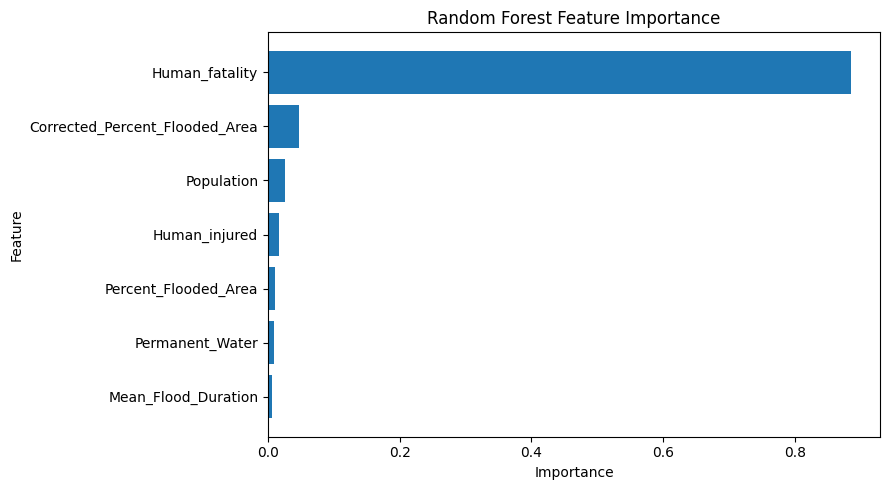

In [19]:
# ==========================================
# STEP 6: FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(9, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# STEP 7: CHECK RELATIONSHIP WITH DFSI
# ==========================================

correlation = train_df[features + ["DFSI"]].corr()["DFSI"] \
    .drop("DFSI") \
    .sort_values(ascending=False)

print("Correlation with DFSI:")
print(correlation)

Correlation with DFSI:
Human_fatality                    0.542685
Population                        0.532248
Mean_Flood_Duration               0.347082
Corrected_Percent_Flooded_Area    0.314312
Percent_Flooded_Area              0.274290
Human_injured                     0.245098
Permanent_Water                   0.005459
Name: DFSI, dtype: float64


In [21]:
# Check the relationship between fatalities and DFSI
print("Human_fatality vs DFSI:")
display(
    train_df[["Human_fatality", "DFSI"]]
    .sort_values("Human_fatality", ascending=False)
    .head(15)
)

Human_fatality vs DFSI:


,Human_fatality,DFSI
207,1726,18.239275
747,1636,16.958822
743,1546,18.057990
742,1373,16.914468
746,1324,16.768504
427,1016,15.096322
441,689,18.687114
756,548,18.018981
425,547,17.524812
760,435,18.910884


In [22]:
# ==========================================
# STEP 8: LEAKAGE-CONTROLLED MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Exclude variables that represent human impact
safe_features = [
    "Percent_Flooded_Area",
    "Permanent_Water",
    "Corrected_Percent_Flooded_Area",
    "Population",
    "Mean_Flood_Duration"
]

X_safe = train_df[safe_features]
y_safe = train_df["DFSI"]

X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe,
    y_safe,
    test_size=0.20,
    random_state=42
)

safe_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

safe_model.fit(X_train_safe, y_train_safe)

y_pred_safe = safe_model.predict(X_test_safe)

mae_safe = mean_absolute_error(y_test_safe, y_pred_safe)
rmse_safe = np.sqrt(mean_squared_error(y_test_safe, y_pred_safe))
r2_safe = r2_score(y_test_safe, y_pred_safe)

print("Leakage-Controlled Model Performance")
print("------------------------------------")
print(f"MAE  : {mae_safe:.4f}")
print(f"RMSE : {rmse_safe:.4f}")
print(f"R²   : {r2_safe:.4f}")

Leakage-Controlled Model Performance
------------------------------------
MAE  : 1.3212
RMSE : 1.7824
R²   : 0.5827


In [23]:
# ==========================================
# STEP 9: 5-FOLD CROSS-VALIDATION
# ==========================================

from sklearn.model_selection import KFold, cross_validate

X_full = train_df[features]
y_full = train_df["DFSI"]

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    rf_model,
    X_full,
    y_full,
    cv=cv,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)

print("5-Fold Cross-Validation")
print("-----------------------")

print(f"R²   : {cv_results['test_R2'].mean():.4f} "
      f"+/- {cv_results['test_R2'].std():.4f}")

print(f"MAE  : {-cv_results['test_MAE'].mean():.4f} "
      f"+/- {cv_results['test_MAE'].std():.4f}")

print(f"RMSE : {-cv_results['test_RMSE'].mean():.4f} "
      f"+/- {cv_results['test_RMSE'].std():.4f}")

5-Fold Cross-Validation
-----------------------
R²   : 0.9498 +/- 0.0060
MAE  : 0.4869 +/- 0.0142
RMSE : 0.6478 +/- 0.0239


In [24]:
# ==========================================
# STEP 10: FINAL MODEL TRAINING
# ==========================================

from sklearn.ensemble import RandomForestRegressor
import joblib
import os
import json

# Features and target
X_final = train_df[features]
y_final = train_df["DFSI"]

# Train final model on all available data
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final, y_final)

print("Final model trained on:", len(X_final), "districts")

Final model trained on: 815 districts


In [25]:
# ==========================================
# STEP 11: SAVE MODEL
# ==========================================

os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(
    final_model,
    "models/terrashield_dfsi_random_forest.pkl"
)

# Save feature list
with open("models/terrashield_features.json", "w") as f:
    json.dump(features, f, indent=4)

print("Model saved successfully.")
print("Path: models/terrashield_dfsi_random_forest.pkl")
print("Features saved: models/terrashield_features.json")

Model saved successfully.
Path: models/terrashield_dfsi_random_forest.pkl
Features saved: models/terrashield_features.json


In [26]:
# ==========================================
# STEP 12: TEST SAVED MODEL
# ==========================================

import joblib
import json
import pandas as pd

# Load model
loaded_model = joblib.load(
    "models/terrashield_dfsi_random_forest.pkl"
)

# Load features
with open("models/terrashield_features.json", "r") as f:
    loaded_features = json.load(f)

print("Loaded model successfully.")
print("Features:", loaded_features)

# Test prediction using the first district
sample = train_df[loaded_features].iloc[[0]]

prediction = loaded_model.predict(sample)[0]

actual = train_df["DFSI"].iloc[0]
district = train_df["Dist_Name"].iloc[0]

print("\nTest Prediction")
print("----------------")
print("District :", district)
print(f"Actual DFSI    : {actual:.4f}")
print(f"Predicted DFSI : {prediction:.4f}")
print(f"Difference     : {abs(actual - prediction):.4f}")

Loaded model successfully.
Features: ['Percent_Flooded_Area', 'Permanent_Water', 'Corrected_Percent_Flooded_Area', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

Test Prediction
----------------
District : dadra & nagar haveli
Actual DFSI    : 9.8202
Predicted DFSI : 10.5916
Difference     : 0.7714


In [27]:
# ==========================================
# STEP 13: DFSI RISK DISTRIBUTION
# ==========================================

print("DFSI range:")
print(f"Minimum: {train_df['DFSI'].min():.4f}")
print(f"Maximum: {train_df['DFSI'].max():.4f}")

print("\nDFSI quartiles:")
print(train_df["DFSI"].quantile([0.20, 0.40, 0.60, 0.80]))

print("\nDFSI descriptive statistics:")
print(train_df["DFSI"].describe())

DFSI range:
Minimum: 4.2445
Maximum: 19.3006

DFSI quartiles:
0.2    11.121014
0.4    13.657683
0.6    15.022279
0.8    16.370916
Name: DFSI, dtype: float64

DFSI descriptive statistics:
count    815.000000
mean      13.827158
std        2.913437
min        4.244485
25%       11.752288
50%       14.465289
75%       16.031950
max       19.300564
Name: DFSI, dtype: float64


In [28]:
# ==========================================
# STEP 14: DFSI RISK CLASSIFICATION
# ==========================================

def classify_dfsi(dfsi):
    if dfsi < 11.121014:
        return "Low"
    elif dfsi < 13.657683:
        return "Moderate"
    elif dfsi < 15.022279:
        return "High"
    else:
        return "Very High"


# Apply classification to actual DFSI values
train_df["Risk_Level"] = train_df["DFSI"].apply(classify_dfsi)

print("Risk level distribution:")
print(train_df["Risk_Level"].value_counts())

print("\nPercentage distribution:")
print(
    train_df["Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Risk level distribution:
Risk_Level
Very High    326
Low          163
High         163
Moderate     163
Name: count, dtype: int64

Percentage distribution:
Risk_Level
Very High    40.0
Low          20.0
High         20.0
Moderate     20.0
Name: proportion, dtype: float64


In [29]:
# ==========================================
# STEP 15: TERRASHIELD DFSI PREDICTOR
# ==========================================

def predict_dfsi(
    percent_flooded_area,
    permanent_water,
    corrected_percent_flooded_area,
    human_fatality,
    human_injured,
    population,
    mean_flood_duration
):
    input_data = pd.DataFrame([{
        "Percent_Flooded_Area": percent_flooded_area,
        "Permanent_Water": permanent_water,
        "Corrected_Percent_Flooded_Area": corrected_percent_flooded_area,
        "Human_fatality": human_fatality,
        "Human_injured": human_injured,
        "Population": population,
        "Mean_Flood_Duration": mean_flood_duration
    }])

    predicted_dfsi = final_model.predict(input_data[features])[0]

    risk_level = classify_dfsi(predicted_dfsi)

    return {
        "DFSI": round(predicted_dfsi, 4),
        "Risk_Level": risk_level
    }


# Example using the first district
row = train_df.iloc[0]

result = predict_dfsi(
    row["Percent_Flooded_Area"],
    row["Permanent_Water"],
    row["Corrected_Percent_Flooded_Area"],
    row["Human_fatality"],
    row["Human_injured"],
    row["Population"],
    row["Mean_Flood_Duration"]
)

print("TerraShield Prediction")
print("----------------------")
print("District:", row["Dist_Name"])
print("DFSI:", result["DFSI"])
print("Risk Level:", result["Risk_Level"])

TerraShield Prediction
----------------------
District: dadra & nagar haveli
DFSI: 10.5916
Risk Level: Low


In [30]:
import os

print(os.path.exists("models/terrashield_dfsi_random_forest.pkl"))
print(os.path.exists("models/terrashield_features.json"))

True
True


In [31]:
import joblib

model = joblib.load("models/terrashield_dfsi_random_forest.pkl")

print(model)
print("Number of trees:", model.n_estimators)
print("Model type:", type(model).__name__)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=4,
                      n_estimators=300, n_jobs=-1, random_state=42)
Number of trees: 300
Model type: RandomForestRegressor


In [32]:
import os

model_path = "models/terrashield_dfsi_random_forest.pkl"

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 7.50 MB


In [33]:
# ==========================================
# STEP 16: BATCH PREDICTIONS FOR ALL DISTRICTS
# ==========================================

# Use the final trained model
predictions = final_model.predict(train_df[features])

# Create results dataframe
results_df = train_df[["Dist_Name", "State_Name", "DFSI"]].copy()

results_df["Predicted_DFSI"] = predictions
results_df["Prediction_Error"] = (
    results_df["DFSI"] - results_df["Predicted_DFSI"]
).abs()

results_df["Risk_Level"] = results_df["Predicted_DFSI"].apply(
    classify_dfsi
)

# Round values for readability
results_df["Predicted_DFSI"] = results_df["Predicted_DFSI"].round(4)
results_df["Prediction_Error"] = results_df["Prediction_Error"].round(4)

print("Batch prediction completed.")
print("Number of districts:", len(results_df))

display(results_df.head(10))

Batch prediction completed.
Number of districts: 815


,Dist_Name,State_Name,DFSI,Predicted_DFSI,Prediction_Error,Risk_Level
0,dadra & nagar haveli,DADRA & NAGAR HAVE,9.820211,10.5916,0.7714,Low
1,daman,DAMAN & DIU,5.233751,5.8772,0.6434,Low
2,diu,DAMAN & DIU,4.269142,5.1251,0.8559,Low
3,north & middle andaman,ANDAMAN & NICOBAR,7.462575,7.5418,0.0792,Low
4,south andaman,ANDAMAN & NICOBAR,8.360463,8.5264,0.1660,Low
5,nicobars,ANDAMAN & NICOBAR,4.664727,6.0811,1.4164,Low
6,srikakulam,ANDHRA PRADESH,15.261049,15.5013,0.2402,Very High
7,vizianagaram,ANDHRA PRADESH,15.961002,15.8665,0.0945,Very High
8,visakhapatnam,ANDHRA PRADESH,17.206749,16.8115,0.3952,Very High
9,krishna,ANDHRA PRADESH,15.957324,16.2315,0.2741,Very High


In [34]:
# ==========================================
# STEP 17: BATCH PREDICTION SUMMARY
# ==========================================

print("Risk Level Distribution:")
print(results_df["Risk_Level"].value_counts())

print("\nAverage Prediction Error:")
print(results_df["Prediction_Error"].mean())

print("\nBest predictions:")
display(
    results_df.sort_values("Prediction_Error").head(10)
)

print("\nLargest prediction errors:")
display(
    results_df.sort_values("Prediction_Error", ascending=False).head(10)
)

Risk Level Distribution:
Risk_Level
Very High    334
Low          163
Moderate     160
High         158
Name: count, dtype: int64

Average Prediction Error:
0.2568413496932515

Best predictions:


,Dist_Name,State_Name,DFSI,Predicted_DFSI,Prediction_Error,Risk_Level
72,biswanath,ASSAM,14.377847,14.3781,0.0003,High
558,firozpur,PUNJAB,14.946469,14.9469,0.0004,High
319,dharwad,KARNATAKA,15.729609,15.7281,0.0015,Very High
92,banka,BIHAR,15.163695,15.1620,0.0017,Very High
103,nalanda,BIHAR,16.168936,16.1706,0.0017,Very High
202,mahisagar,GUJARAT,13.187004,13.1891,0.0021,Moderate
322,chitradurga,KARNATAKA,14.586115,14.5834,0.0027,High
659,shrawasti,UTTAR PRADESH,14.636055,14.6388,0.0028,High
615,mahabubabad,TELANGANA,9.983654,9.9807,0.0030,Low
310,bidar,KARNATAKA,15.210263,15.2071,0.0031,Very High



Largest prediction errors:


,Dist_Name,State_Name,DFSI,Predicted_DFSI,Prediction_Error,Risk_Level
122,chandigarh,CHANDIGARH,8.444720,9.9597,1.5150,Low
5,nicobars,ANDAMAN & NICOBAR,4.664727,6.0811,1.4164,Low
606,hyderabad,TELANGANA,10.461370,11.7257,1.2643,Moderate
458,mumbai suburban,MAHARASHTRA,12.892295,13.9854,1.0931,High
593,pratapgarh,UTTAR PRADESH,17.176323,16.0912,1.0851,Very High
741,pratapgarh,RAJASTHAN,15.135219,16.2202,1.0850,Very High
121,aurangabad,MAHARASHTRA,16.297589,17.3635,1.0659,Very High
737,pratapgarh,RAJASTHAN,15.135219,16.1940,1.0588,Very High
25,east siang,ARUNACHAL PRADESH,13.929163,12.8770,1.0522,Moderate
285,mirpur,JAMMU & KASHMIR,9.948679,11.0000,1.0513,Low


In [35]:
# ==========================================
# STEP 18: SAVE BATCH PREDICTIONS
# ==========================================

import os

os.makedirs("results", exist_ok=True)

results_path = "results/dfsi_predictions.csv"

results_df.to_csv(results_path, index=False)

print("Predictions saved successfully.")
print("Path:", results_path)
print("Rows:", len(results_df))

Predictions saved successfully.
Path: results/dfsi_predictions.csv
Rows: 815


In [37]:
import json
import joblib
import pandas as pd


MODEL_PATH = "models/terrashield_dfsi_random_forest.pkl"
FEATURES_PATH = "models/terrashield_features.json"


# Load model
model = joblib.load(MODEL_PATH)

# Load feature list
with open(FEATURES_PATH, "r") as f:
    FEATURES = json.load(f)


def classify_dfsi(dfsi):
    """
    Convert DFSI into a TerraShield risk level.
    """

    if dfsi < 11.121014:
        return "Low"

    elif dfsi < 13.657683:
        return "Moderate"

    elif dfsi < 15.022279:
        return "High"

    else:
        return "Very High"


def predict_dfsi(
    percent_flooded_area,
    permanent_water,
    corrected_percent_flooded_area,
    human_fatality,
    human_injured,
    population,
    mean_flood_duration
):
    """
    Predict DFSI and risk level for a district.
    """

    data = pd.DataFrame([{
        "Percent_Flooded_Area": percent_flooded_area,
        "Permanent_Water": permanent_water,
        "Corrected_Percent_Flooded_Area": corrected_percent_flooded_area,
        "Human_fatality": human_fatality,
        "Human_injured": human_injured,
        "Population": population,
        "Mean_Flood_Duration": mean_flood_duration
    }])

    # Ensure correct feature order
    data = data[FEATURES]

    # Prediction
    predicted_dfsi = float(model.predict(data)[0])

    # Risk classification
    risk_level = classify_dfsi(predicted_dfsi)

    return {
        "DFSI": round(predicted_dfsi, 4),
        "Risk_Level": risk_level
    }

In [38]:
# ==========================================
# STEP 19: TEST SAVED MODEL
# ==========================================

import joblib
import json
import pandas as pd

# Load saved model
model = joblib.load(
    "models/terrashield_dfsi_random_forest.pkl"
)

# Load feature configuration
with open("models/terrashield_features.json", "r") as f:
    FEATURES = json.load(f)

print("Model loaded successfully.")
print("Features:", FEATURES)


# Risk classification
def classify_dfsi(dfsi):
    if dfsi < 11.121014:
        return "Low"
    elif dfsi < 13.657683:
        return "Moderate"
    elif dfsi < 15.022279:
        return "High"
    else:
        return "Very High"


# Prediction function
def predict_dfsi(
    percent_flooded_area,
    permanent_water,
    corrected_percent_flooded_area,
    human_fatality,
    human_injured,
    population,
    mean_flood_duration
):

    data = pd.DataFrame([{
        "Percent_Flooded_Area": percent_flooded_area,
        "Permanent_Water": permanent_water,
        "Corrected_Percent_Flooded_Area": corrected_percent_flooded_area,
        "Human_fatality": human_fatality,
        "Human_injured": human_injured,
        "Population": population,
        "Mean_Flood_Duration": mean_flood_duration
    }])

    data = data[FEATURES]

    predicted_dfsi = float(model.predict(data)[0])

    risk_level = classify_dfsi(predicted_dfsi)

    return {
        "DFSI": round(predicted_dfsi, 4),
        "Risk_Level": risk_level
    }


# Test using first district
row = train_df.iloc[0]

result = predict_dfsi(
    row["Percent_Flooded_Area"],
    row["Permanent_Water"],
    row["Corrected_Percent_Flooded_Area"],
    row["Human_fatality"],
    row["Human_injured"],
    row["Population"],
    row["Mean_Flood_Duration"]
)

print("\nTerraShield Prediction")
print("----------------------")
print("District:", row["Dist_Name"])
print("DFSI:", result["DFSI"])
print("Risk Level:", result["Risk_Level"])

Model loaded successfully.
Features: ['Percent_Flooded_Area', 'Permanent_Water', 'Corrected_Percent_Flooded_Area', 'Human_fatality', 'Human_injured', 'Population', 'Mean_Flood_Duration']

TerraShield Prediction
----------------------
District: dadra & nagar haveli
DFSI: 10.5916
Risk Level: Low


In [39]:
# ==========================================
# STEP 20: PREDICT ANY DISTRICT
# ==========================================

def predict_district(district_name):

    district_name = district_name.strip().lower()

    # Find district
    district = train_df[
        train_df["Dist_Name"] == district_name
    ]

    if district.empty:
        return f"District '{district_name}' not found."

    row = district.iloc[0]

    # Prepare input
    input_data = pd.DataFrame([{
        "Percent_Flooded_Area": row["Percent_Flooded_Area"],
        "Permanent_Water": row["Permanent_Water"],
        "Corrected_Percent_Flooded_Area": row["Corrected_Percent_Flooded_Area"],
        "Human_fatality": row["Human_fatality"],
        "Human_injured": row["Human_injured"],
        "Population": row["Population"],
        "Mean_Flood_Duration": row["Mean_Flood_Duration"]
    }])

    # Predict
    predicted_dfsi = float(
        model.predict(input_data[FEATURES])[0]
    )

    risk = classify_dfsi(predicted_dfsi)

    print("================================")
    print("       TERRASHIELD RESULT")
    print("================================")
    print("District :", row["Dist_Name"].title())
    print("State    :", row["State_Name"])
    print(f"DFSI     : {predicted_dfsi:.4f}")
    print("Risk     :", risk)
    print("================================")

    return {
        "District": row["Dist_Name"],
        "State": row["State_Name"],
        "Predicted_DFSI": round(predicted_dfsi, 4),
        "Risk_Level": risk
    }

In [40]:
predict_district("begusarai")

       TERRASHIELD RESULT
District : Begusarai
State    : BIHAR
DFSI     : 17.2805
Risk     : Very High


{'District': 'begusarai',
 'State': 'BIHAR',
 'Predicted_DFSI': 17.2805,
 'Risk_Level': 'Very High'}

In [41]:
predict_district("patna")

       TERRASHIELD RESULT
District : Patna
State    : BIHAR
DFSI     : 18.8462
Risk     : Very High


{'District': 'patna',
 'State': 'BIHAR',
 'Predicted_DFSI': 18.8462,
 'Risk_Level': 'Very High'}

In [42]:
predict_district("mumbai suburban")

       TERRASHIELD RESULT
District : Mumbai Suburban
State    : MAHARASHTRA
DFSI     : 13.9854
Risk     : High


{'District': 'mumbai suburban',
 'State': 'MAHARASHTRA',
 'Predicted_DFSI': 13.9854,
 'Risk_Level': 'High'}

In [59]:
import os

project = "/content/drive/MyDrive/soa_ideathon_s6"

folders = [
    "notebooks",
    "data/raw",
    "data/processed",
    "models",
    "results",
    "src"
]

for folder in folders:
    os.makedirs(os.path.join(project, folder), exist_ok=True)

print("TerraShield project structure created.")

TerraShield project structure created.


In [60]:
for root, dirs, files in os.walk(project):
    level = root.replace(project, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

soa_ideathon_s6/
    data/
        Gaya/
            sentinel1/
                S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_151E_COG.SAFE/
                    S1A_IW_GRDH_1SDV_20260520T001231_20260520T001256_064593_0822ED_569E.SAFE-report-20260520T022943.pdf
                    manifest.safe
                    annotation/
                        s1a-iw-grd-vv-20260520t001231-20260520t001256-064593-0822ed-001-cog.xml
                        s1a-iw-grd-vh-20260520t001231-20260520t001256-064593-0822ed-002-cog.xml
                        calibration/
                            noise-s1a-iw-grd-vv-20260520t001231-20260520t001256-064593-0822ed-001-cog.xml
                            noise-s1a-iw-grd-vh-20260520t001231-20260520t001256-064593-0822ed-002-cog.xml
                            calibration-s1a-iw-grd-vv-20260520t001231-20260520t001256-064593-0822ed-001-cog.xml
                            calibration-s1a-iw-grd-vh-20260520t001231-20260520t001256-064593-0822ed-002